## Part 0: Import and Devices

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import time, os

os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 12

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dtype  = torch.float64
torch.set_default_dtype(dtype)

print(f"PyTorch: {torch.__version__}")
print(f"Device:  {device}")

PyTorch: 2.8.0+cu128
Device:  cuda


## Part 1: Common parameters

After running this section, simply skip to the cell corresponding to the specific case and run it.

In [2]:
# =================== GeometryGeometry===================
Ri   = 0.71   # mm
Ro   = 1.10   # mm
Rm   = 0.97   # mm  (Ri + HM = 0.71 + 0.26)
L    = 2.5    # mm

# =================== grid  ===================
nr  = 31     
nz  = 81     

# =================== HGO Material Parameter (Singler Layer/ Case 1) ===================
params_single = {
    'C10':   0.003 / 2.0,       
    'D':     0.1,       
    'k1':    0.0023632,   
    'k2':    0.8393,     
    'kappa': 0.0,         
    'gamma': 61.0,        
}

# =================== HGO Material Parameter (Bi-Layer/ Case 2) ===================
params_media = {
    'C10':   0.003 / 2.0,
    'D':     0.1,
    'k1':    0.0023632,
    'k2':    0.8393,
    'kappa': 0.0,
    'gamma': 61.0,        
}

params_adventitia = {
    'C10':   0.0003 / 2.0,
    'D':     0.1,
    'k1':    0.00056200,
    'k2':    0.7112,
    'kappa': 0.0,
    'gamma': 28.0,        
}
# =================== Load ===================
p_max      = 0.02133    #  MPa
dz_max     = 1.75     #  mm (Case 3)
n_steps    = 4       # 

print(f"Geometry: Ri={Ri}, Ro={Ro}, Rm={Rm}, L={L} mm")
print(f"Grid:     {nr} x {nz} = {nr*nz} points")
print(f"Loading:  p_max={p_max} MPa, dz_max={dz_max} mm, {n_steps} steps")

Geometry: Ri=0.71, Ro=1.1, Rm=0.97, L=2.5 mm
Grid:     31 x 81 = 2511 points
Loading:  p_max=0.02133 MPa, dz_max=1.75 mm, 4 steps


## Part 2: Common Module

In [3]:
# =================== Simpson  ===================
def simpson_weights_1d(n, h, dev=device):
    assert n >= 3 and n % 2 == 1
    w = torch.ones(n, dtype=dtype, device=dev)
    for i in range(1, n - 1):
        w[i] = 4.0 if i % 2 == 1 else 2.0
    w *= h / 3.0
    return w

def simpson_weights_2d_cyl(nr, nz, dr, dz, r_nodes, dev=device):
    wr = simpson_weights_1d(nr, dr, dev)
    wz = simpson_weights_1d(nz, dz, dev)
    wr_cyl = wr * r_nodes * 2.0 * np.pi
    W2d = torch.outer(wr_cyl, wz)
    return W2d.flatten()

def simpson_weights_1d_cyl_surface(nz, dz, R_inner, dev=device):
    wz = simpson_weights_1d(nz, dz, dev)
    return wz * 2.0 * np.pi * R_inner

print("Simpson weights: OK")

Simpson weights: OK


In [4]:
def create_geometry_rz(R_inner, R_outer, length, n_r, n_z):
    r = torch.linspace(R_inner, R_outer, n_r, dtype=dtype, device=device)
    z = torch.linspace(0, length, n_z, dtype=dtype, device=device)
    R, Z = torch.meshgrid(r, z, indexing='ij')
    RZdata = torch.stack([R.flatten(), Z.flatten()], dim=1)
    return RZdata, R, Z, r

print("Geometry builder: OK")

Geometry builder: OK


In [5]:
def get_fiber_directions(gamma_deg):
    gamma = np.deg2rad(gamma_deg)
    sg, cg = np.sin(gamma), np.cos(gamma)
    a1 = torch.tensor([0.0, sg, cg], dtype=dtype, device=device)
    a2 = torch.tensor([0.0, -sg, cg], dtype=dtype, device=device)
    return a1, a2

print("Fiber directions: OK")

Fiber directions: OK


In [6]:

class DEM_Network(nn.Module):

    def __init__(self, R_in, R_out, length,
                 layers=[2, 64, 64, 64, 64, 64, 2]):
        super().__init__()
        self.R_in  = R_in
        self.R_out = R_out
        self.L     = length
        self.layers_list = layers

        mods = []
        for i in range(len(layers) - 1):
            mods.append(nn.Linear(layers[i], layers[i+1]))
            if i < len(layers) - 2:
                mods.append(nn.Tanh())
        self.net = nn.Sequential(*mods).to(dtype=dtype, device=device)

        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, rz):
        r_norm = 2.0 * (rz[:, 0:1] - self.R_in) / (self.R_out - self.R_in) - 1.0
        z_norm = 2.0 * rz[:, 1:2] / self.L - 1.0
        inp = torch.cat([r_norm, z_norm], dim=1)
        return self.net(inp)

print("DEM Network: OK")

DEM Network: OK


In [7]:
# =================== Hard BC ===================
def apply_hard_BC_pressure_only(rz, y_hat, L_val):
    z = rz[:, 1]
    xi_z = z / L_val

    ur = y_hat[:, 0]                          
    uz = xi_z * (1.0 - xi_z) * y_hat[:, 1]   

    return torch.stack([ur, uz], dim=1)
def apply_hard_BC_pressure_axial(rz, y_hat, L_val, delta_z):
    z = rz[:, 1]
    xi_z = z / L_val

    ur = y_hat[:, 0]                                              
    uz = (xi_z - 0.5) * delta_z + xi_z * (1.0 - xi_z) * y_hat[:, 1]  

    return torch.stack([ur, uz], dim=1)

print("Hard BC functions: OK")

Hard BC functions: OK


In [8]:
# =================== Deformation Gradient Tensor(Cylinder) ===================
def compute_deformation_gradient(u_pred, RZdata):
    # F = [[du_r/dr+1, 0,        du_r/dz   ],
    #      [0,         u_r/r+1,  0          ],
    #      [du_z/dr,   0,        du_z/dz+1  ]]
    N = u_pred.shape[0]
    r = RZdata[:, 0]

    grad_ur = torch.autograd.grad(
        u_pred[:, 0].sum(), RZdata, create_graph=True, retain_graph=True)[0]
    grad_uz = torch.autograd.grad(
        u_pred[:, 1].sum(), RZdata, create_graph=True, retain_graph=True)[0]

    dur_dr = grad_ur[:, 0]
    dur_dz = grad_ur[:, 1]
    duz_dr = grad_uz[:, 0]
    duz_dz = grad_uz[:, 1]
    u_r    = u_pred[:, 0]

    F = torch.zeros(N, 3, 3, dtype=dtype, device=device)
    F[:, 0, 0] = dur_dr + 1.0       # F_rr
    F[:, 0, 2] = dur_dz             # F_rz
    F[:, 1, 1] = u_r / r + 1.0      # F_theta_theta
    F[:, 2, 0] = duz_dr             # F_zr
    F[:, 2, 2] = duz_dz + 1.0       # F_zz
    return F

print("Kinematics: OK")

Kinematics: OK


In [9]:
# =================== HGO Strain energy density ===================
def compute_hgo_energy(F, params, a1, a2):

    C10   = params['C10']
    D_vol = params['D']
    k1    = params['k1']
    k2    = params['k2']
    kap   = params['kappa']

    C  = torch.bmm(F.transpose(1, 2), F)
    I1 = C[:, 0, 0] + C[:, 1, 1] + C[:, 2, 2]
    J  = torch.det(F).clamp(min=1e-6)
    J_m23  = J.pow(-2.0 / 3.0)
    I1_bar = J_m23 * I1

    Ca1 = torch.einsum('nij,j->ni', C, a1)
    Ca2 = torch.einsum('nij,j->ni', C, a2)
    I4_1_bar = J_m23 * torch.einsum('ni,i->n', Ca1, a1)
    I4_2_bar = J_m23 * torch.einsum('ni,i->n', Ca2, a2)

    W_iso = C10 * (I1_bar - 3.0)

    E1 = kap * (I1_bar - 3.0) + (1.0 - 3.0*kap) * (I4_1_bar - 1.0)
    E2 = kap * (I1_bar - 3.0) + (1.0 - 3.0*kap) * (I4_2_bar - 1.0)
    E1 = torch.clamp(E1, min=0.0, max=10.0)
    E2 = torch.clamp(E2, min=0.0, max=10.0)

    W_fib = (k1 / (2.0*k2)) * (
        (torch.exp(k2 * E1**2) - 1.0) + (torch.exp(k2 * E2**2) - 1.0))

    W_vol = (1.0 / D_vol) * ((J**2 - 1.0) / 2.0 - torch.log(J))

    return W_iso + W_fib + W_vol, J

print("HGO energy: OK")

HGO energy: OK


In [10]:
def solve_one_step(net, RZdata, vol_weights, surf_weights,
                   mask_ri, p_val, compute_energy_fn, apply_bc_fn,
                   adam_epochs=800, lbfgs_epochs=200,
                   adam_lr=5e-4, verbose=True):

    loss_history = []
    opt_adam = torch.optim.Adam(net.parameters(), lr=adam_lr)
    best_loss = float('inf')
    plateau_count = 0
    loss_val = 0.0


    Ri_val = RZdata[mask_ri, 0].mean().item()  
    wz = surf_weights / (2.0 * np.pi * Ri_val)

    for ep in range(adam_epochs):
        opt_adam.zero_grad()
        rz = RZdata.clone().requires_grad_(True)
        y_hat  = net(rz)
        u_pred = apply_bc_fn(rz, y_hat)
        F = compute_deformation_gradient(u_pred, rz)
        W, J = compute_energy_fn(F)
        strain_energy = torch.sum(W * vol_weights)

        r_inner = Ri_val + u_pred[mask_ri, 0]
        lambda_z_inner = F[mask_ri, 2, 2] 
        pressure_work = p_val * torch.sum(np.pi * (r_inner**2 * lambda_z_inner - Ri_val**2) * wz)
        Pi = strain_energy - pressure_work
        Pi.backward()
        torch.nn.utils.clip_grad_norm_(net.parameters(), max_norm=1.0)
        opt_adam.step()
        loss_val = Pi.item()

        strain_energy_val   = strain_energy.item()
        pressure_work_val   = pressure_work.item()
        loss_history.append(('adam', ep, Pi.item(), strain_energy_val, pressure_work_val))
        
        if abs(best_loss - loss_val) < 1e-10 * max(1.0, abs(best_loss)):
            plateau_count += 1
            if plateau_count >= 80:
                if verbose:
                    print(f"    Adam early stop @ ep {ep}, Pi = {loss_val:.6e}")
                break
        else:
            plateau_count = 0
        best_loss = min(best_loss, loss_val)

    adam_final = loss_val
    lbfgs_iter = [0]

    opt_lbfgs = torch.optim.LBFGS(
        net.parameters(), lr=1.0, max_iter=lbfgs_epochs,
        tolerance_grad=1e-11, tolerance_change=1e-14,
        history_size=100, line_search_fn='strong_wolfe')

    def closure():
        opt_lbfgs.zero_grad()
        rz = RZdata.clone().requires_grad_(True)
        y_hat  = net(rz)
        u_pred = apply_bc_fn(rz, y_hat)
        F = compute_deformation_gradient(u_pred, rz)
        W, J = compute_energy_fn(F)
        strain_energy = torch.sum(W * vol_weights)
        r_inner = Ri_val + u_pred[mask_ri, 0]
        lambda_z_inner = F[mask_ri, 2, 2]
        pressure_work = p_val * torch.sum(np.pi * (r_inner**2 * lambda_z_inner - Ri_val**2) * wz)
        Pi = strain_energy - pressure_work
        Pi.backward()
        torch.nn.utils.clip_grad_norm_(net.parameters(), max_norm=1.0)
        loss_history.append(('lbfgs', lbfgs_iter[0], Pi.item(),
                     strain_energy.item(), pressure_work.item()))
        lbfgs_iter[0] += 1
        return Pi

    final = opt_lbfgs.step(closure)
    if verbose:
        print(f"    Adam final: {adam_final:.6e}  |  L-BFGS final: {final.item():.6e}")

    return final.item(), loss_history

In [11]:
def compute_cauchy_stress_np(F_i, J_i, params, a1_np, a2_np):
    C10, D_vol = params['C10'], params['D']
    k1, k2, kap = params['k1'], params['k2'], params['kappa']
    I3 = np.eye(3)

    J_m23  = J_i ** (-2.0 / 3.0)
    b_bar  = J_m23 * (F_i @ F_i.T)
    I1_bar = np.trace(b_bar)
    
    C_i = F_i.T @ F_i
    I4_1_bar = J_m23 * (a1_np @ C_i @ a1_np)
    I4_2_bar = J_m23 * (a2_np @ C_i @ a2_np)

    E1 = kap * (I1_bar - 3.0) + (1.0 - 3.0 * kap) * (I4_1_bar - 1.0)
    E2 = kap * (I1_bar - 3.0) + (1.0 - 3.0 * kap) * (I4_2_bar - 1.0)
    
    dWdE1 = k1 * E1 * np.exp(k2 * E1**2) if E1 > 0.0 else 0.0
    dWdE2 = k1 * E2 * np.exp(k2 * E2**2) if E2 > 0.0 else 0.0

    Fa1, Fa2 = F_i @ a1_np, F_i @ a2_np
    aa1 = J_m23 * np.outer(Fa1, Fa1)
    aa2 = J_m23 * np.outer(Fa2, Fa2)

    sig_dev_iso = (2.0 / J_i) * C10 * (b_bar - (I1_bar / 3.0) * I3)
    
    sig_dev_aniso_iso = (2.0 / J_i) * kap * (dWdE1 + dWdE2) * (b_bar - (I1_bar / 3.0) * I3)
    
    sig_dev_aniso_fib = (2.0 / J_i) * (1.0 - 3.0 * kap) * (
        dWdE1 * (aa1 - (I4_1_bar / 3.0) * I3) + 
        dWdE2 * (aa2 - (I4_2_bar / 3.0) * I3)
    )
    
    sig_vol = (1.0 / (D_vol * J_i)) * (J_i**2 - 1.0) * I3
 

    # 总 Cauchy 应力
    sig = sig_dev_iso + sig_dev_aniso_iso + sig_dev_aniso_fib + sig_vol

    return sig

In [12]:
# =================== Visualization Part ===================
def visualize_results(net, RZdata_vis, R_grid, Z_grid,
                      compute_energy_fn, apply_bc_fn,
                      params_stress, a1_np, a2_np,
                      case_title="", save_prefix="case",
                      interface_r=None):
    nr_v, nz_v = R_grid.shape
    mid = nz_v // 2

    with torch.no_grad():
        y_hat  = net(RZdata_vis)
        u_pred = apply_bc_fn(RZdata_vis, y_hat)
        u_np   = u_pred.cpu().numpy()

    r_arr = R_grid.cpu().numpy()
    z_arr = Z_grid.cpu().numpy()
    ur = u_np[:, 0].reshape(nr_v, nz_v)
    uz = u_np[:, 1].reshape(nr_v, nz_v)


    rz_g = RZdata_vis.clone().requires_grad_(True)
    y_g  = net(rz_g)
    u_g  = apply_bc_fn(rz_g, y_g)
    F_pred = compute_deformation_gradient(u_g, rz_g)
    _, J_pred = compute_energy_fn(F_pred)
    F_all = F_pred.detach().cpu().numpy().reshape(nr_v, nz_v, 3, 3)
    J_all = J_pred.detach().cpu().numpy().reshape(nr_v, nz_v)

    r_mid = r_arr[:, mid]
    stt, srr, szz = np.zeros(nr_v), np.zeros(nr_v), np.zeros(nr_v)


    for i in range(nr_v):
        if callable(params_stress):
            ps, a1n, a2n = params_stress(r_mid[i])
        else:
            ps, a1n, a2n = params_stress, a1_np, a2_np
        sig = compute_cauchy_stress_np(F_all[i, mid], J_all[i, mid], ps, a1n, a2n)
        srr[i], stt[i], szz[i] = sig[0,0], sig[1,1], sig[2,2]

    # ---- 绘图 ----
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f"DEM — {case_title}", fontsize=14)

    cs = axes[0,0].contourf(z_arr, r_arr, ur, 64, cmap='jet')
    fig.colorbar(cs, ax=axes[0,0]); axes[0,0].set_title('$u_r$ (mm)')
    axes[0,0].set_xlabel('z'); axes[0,0].set_ylabel('r')

    cs = axes[0,1].contourf(z_arr, r_arr, uz, 64, cmap='jet')
    fig.colorbar(cs, ax=axes[0,1]); axes[0,1].set_title('$u_z$ (mm)')
    axes[0,1].set_xlabel('z'); axes[0,1].set_ylabel('r')

    cs = axes[0,2].contourf(z_arr+uz, r_arr+ur, ur, 64, cmap='jet')
    fig.colorbar(cs, ax=axes[0,2]); axes[0,2].set_title('$u_r$ on deformed')
    axes[0,2].set_xlabel('z'); axes[0,2].set_ylabel('r')

    axes[1,0].plot(r_mid, ur[:, mid], 'b-o', ms=4, lw=2)
    axes[1,0].set_xlabel('r (mm)'); axes[1,0].set_ylabel('$u_r$ (mm)')
    axes[1,0].set_title('Radial disp at z=L/2'); axes[1,0].grid(True, alpha=0.3)

    axes[1,1].plot(r_mid, stt, 'r-o', ms=4, lw=2, label='$\sigma_{\\theta\\theta}$')
    axes[1,1].plot(r_mid, srr, 'b-s', ms=4, lw=2, label='$\sigma_{rr}$')
    if interface_r is not None:
        axes[1,1].axvline(interface_r, color='k', ls='--', alpha=0.5, label='Interface')
    axes[1,1].set_xlabel('r'); axes[1,1].set_ylabel('Stress (MPa)')
    axes[1,1].set_title('Stress at z=L/2'); axes[1,1].legend(); axes[1,1].grid(True, alpha=0.3)

    axes[1,2].plot(r_mid, szz, 'g-^', ms=4, lw=2)
    if interface_r is not None:
        axes[1,2].axvline(interface_r, color='k', ls='--', alpha=0.5)
    axes[1,2].set_xlabel('r'); axes[1,2].set_ylabel('$\sigma_{zz}$ (MPa)')
    axes[1,2].set_title('Axial stress'); axes[1,2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{save_prefix}_results.png', dpi=150, bbox_inches='tight')
    plt.show()
    return ur, uz, r_mid, stt, srr, szz

print("Visualization: OK")

Visualization: OK


---
## Case 1: Singler layer + Inner pressuer

Geomery: Ri=0.8, Ro=1.0, L=3.0 (Singler Layer)

BC: z=0 uz=0; z=L uz=0; Inner: p; Outer: free

In [13]:
# =================== Case 1: Preperation ===================
print("="*60)
print("Case 1: Single-layer cylinder + internal pressure")
print("="*60)

RZdata_c1, R_grid_c1, Z_grid_c1, r_nodes_c1 = create_geometry_rz(Ri, Ro, L, nr, nz)
dr_c1 = (Ro - Ri) / (nr - 1)
dz_c1 = L / (nz - 1)
vol_weights_c1  = simpson_weights_2d_cyl(nr, nz, dr_c1, dz_c1, r_nodes_c1)
surf_weights_c1 = simpson_weights_1d_cyl_surface(nz, dz_c1, Ri)
eps = 1e-6
mask_ri_c1 = RZdata_c1[:, 0] < (Ri + eps)

a1_c1, a2_c1 = get_fiber_directions(params_single['gamma'])
net_c1 = DEM_Network(Ri, Ro, L)

def energy_fn_c1(F):
    return compute_hgo_energy(F, params_single, a1_c1, a2_c1)

def bc_fn_c1(rz, y_hat):
    return apply_hard_BC_pressure_only(rz, y_hat, L)

p_steps_c1 = np.linspace(p_max / n_steps, p_max, n_steps)
print(f"Pressure steps: {p_steps_c1}")
print(f"Network params: {sum(p.numel() for p in net_c1.parameters())}")

Case 1: Single-layer cylinder + internal pressure
Pressure steps: [0.0053325 0.010665  0.0159975 0.02133  ]
Network params: 16962


In [14]:
# =================== Case 1: Soler (Oneshot, No transfer Learning) ===================
results_c1 = []
all_loss_history_c1 = []
t0 = time.time()

p_val = p_max   
print(f"--- One-shot: p = {p_val:.4f} MPa ---")

loss, loss_hist = solve_one_step(
    net_c1, RZdata_c1, vol_weights_c1, surf_weights_c1,
    mask_ri_c1, p_val, energy_fn_c1, bc_fn_c1,
    adam_epochs=3000, lbfgs_epochs=800)

results_c1.append({'step': 1, 'p': p_val, 'loss': loss})
all_loss_history_c1.append(loss_hist)

t_total = time.time() - t0
print(f"\nCase 1 total time: {t_total:.0f} s ({t_total/60:.1f} min)")
os.makedirs('./pth', exist_ok=True)
torch.save(net_c1.state_dict(), './pth/case1_dem.pt')


--- One-shot: p = 0.0213 MPa ---
    Adam final: -1.460157e-01  |  L-BFGS final: -1.285237e-01

Case 1 total time: 75 s (1.2 min)


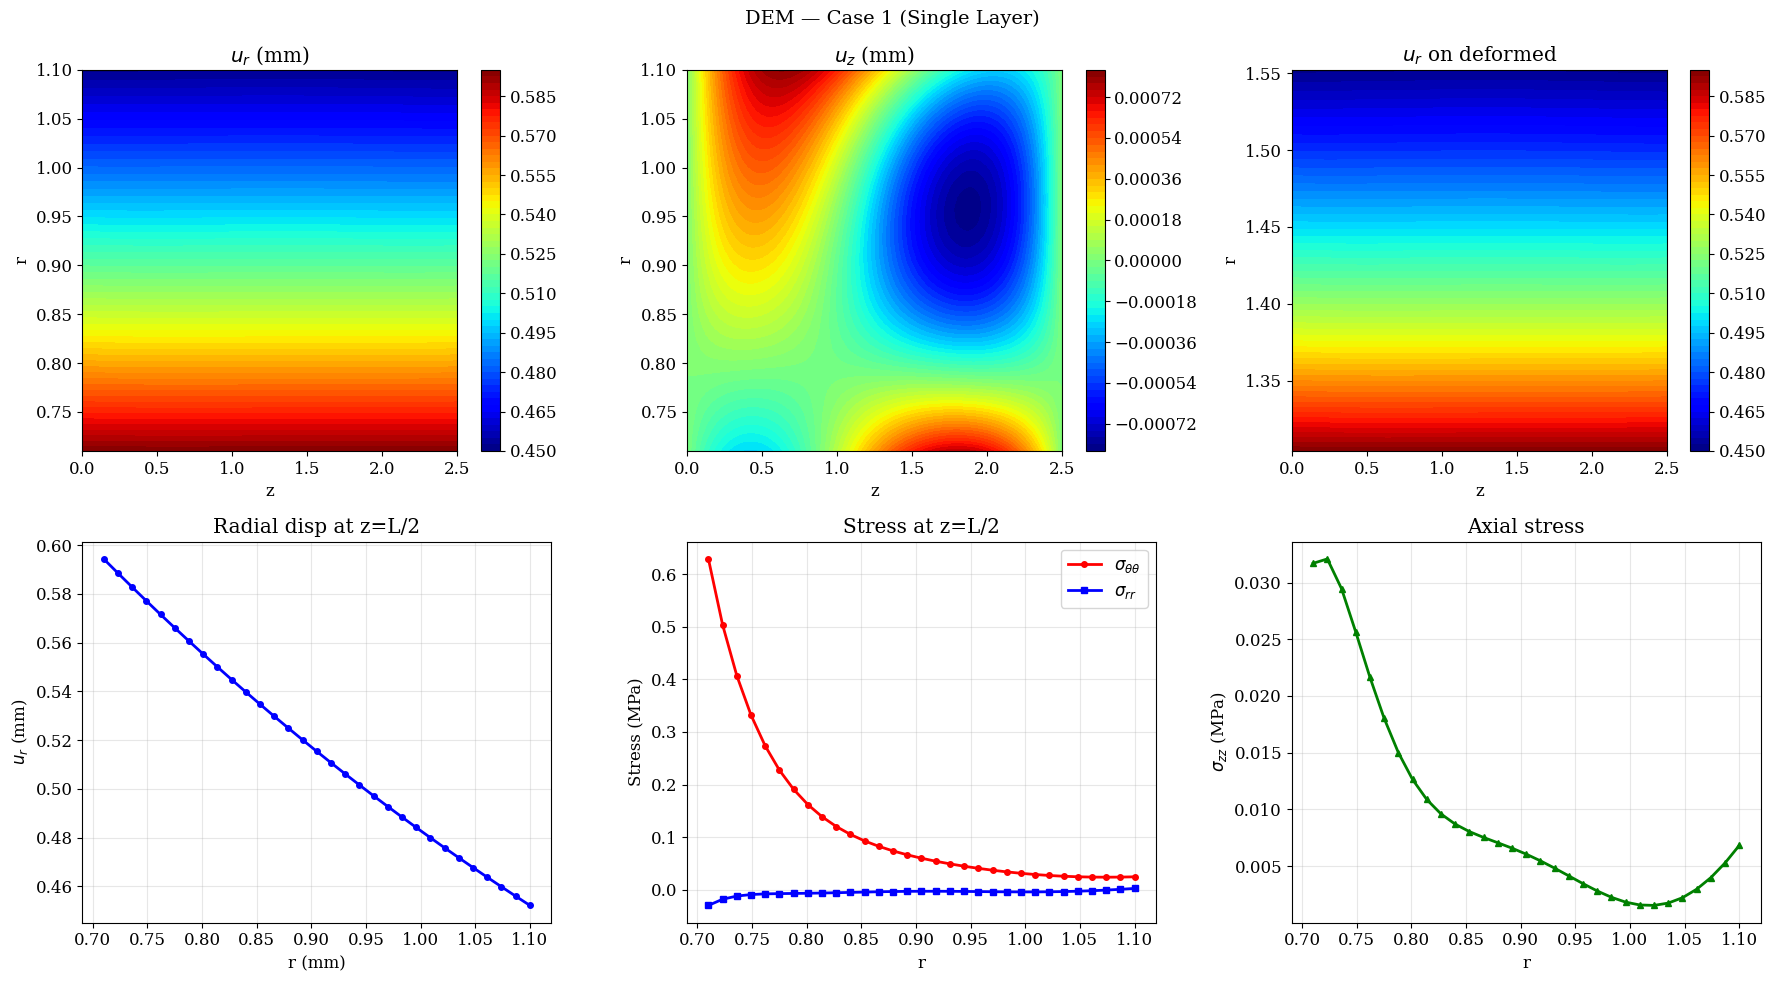

In [15]:
mid = nz // 2

ur_c1, uz_c1, r_mid, stt_c1, srr_c1, szz_c1 = visualize_results(
    net_c1, RZdata_c1, R_grid_c1, Z_grid_c1,
    energy_fn_c1, bc_fn_c1, 
    params_single, a1_c1.cpu().numpy(), a2_c1.cpu().numpy(),
    case_title="Case 1 (Single Layer)", save_prefix="case1"
)

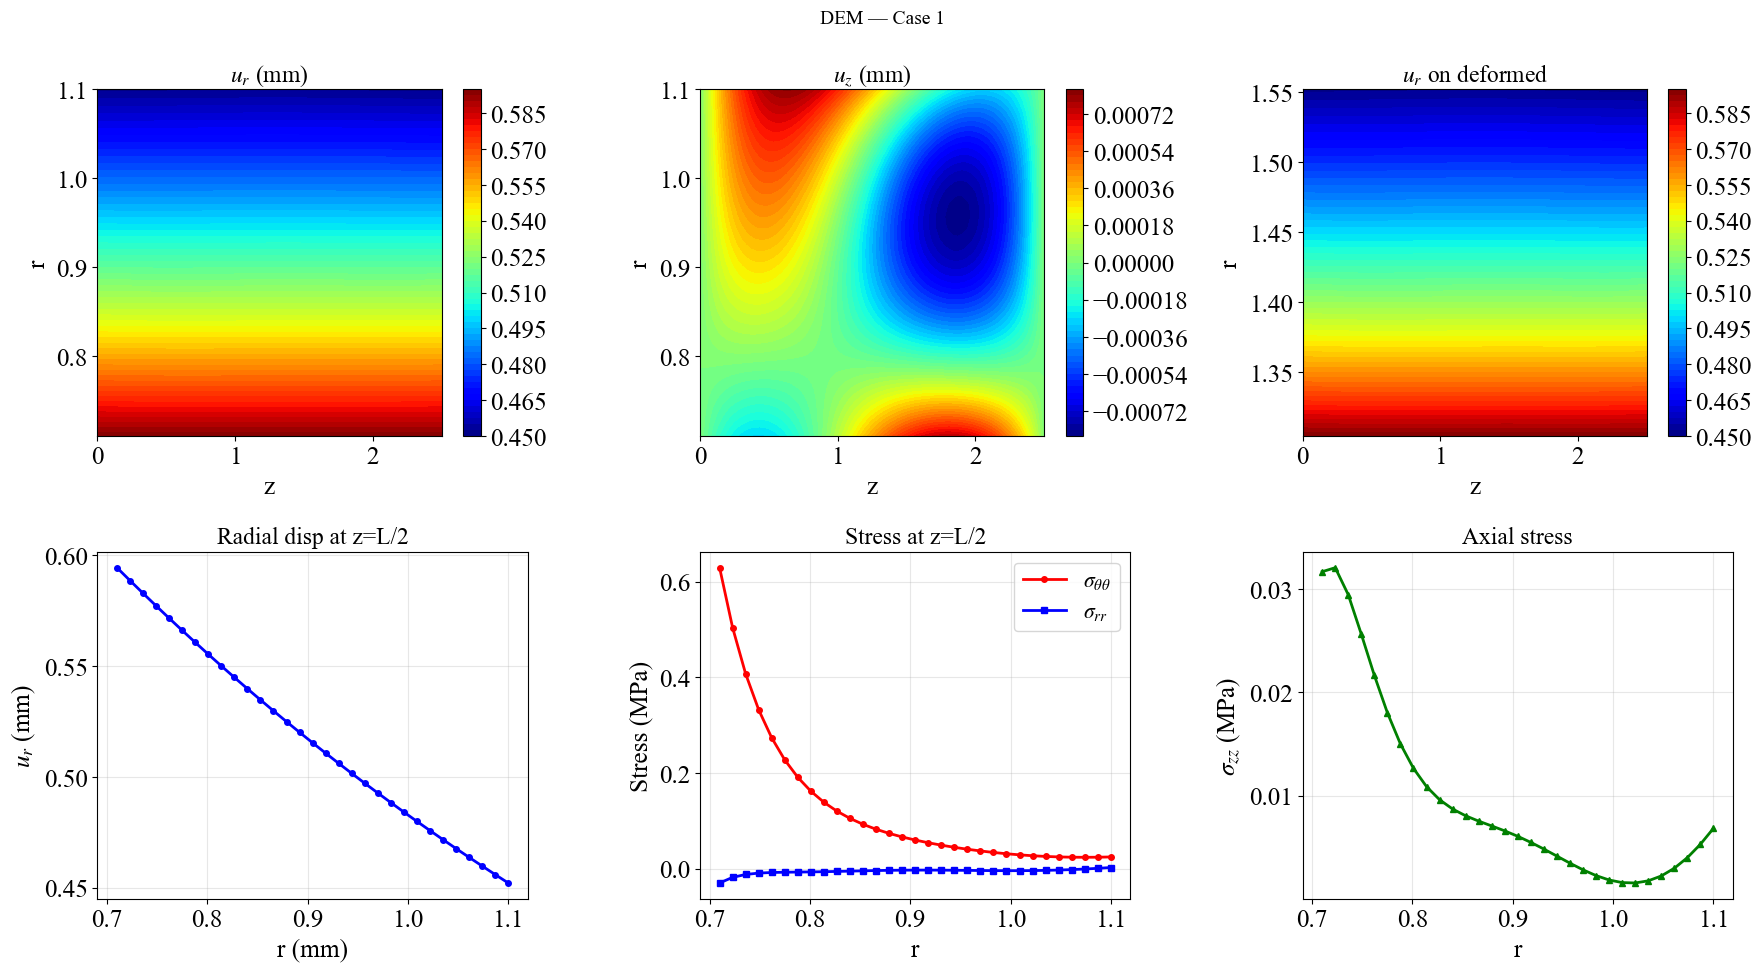

Abaqus data loaded: 106848 nodes.


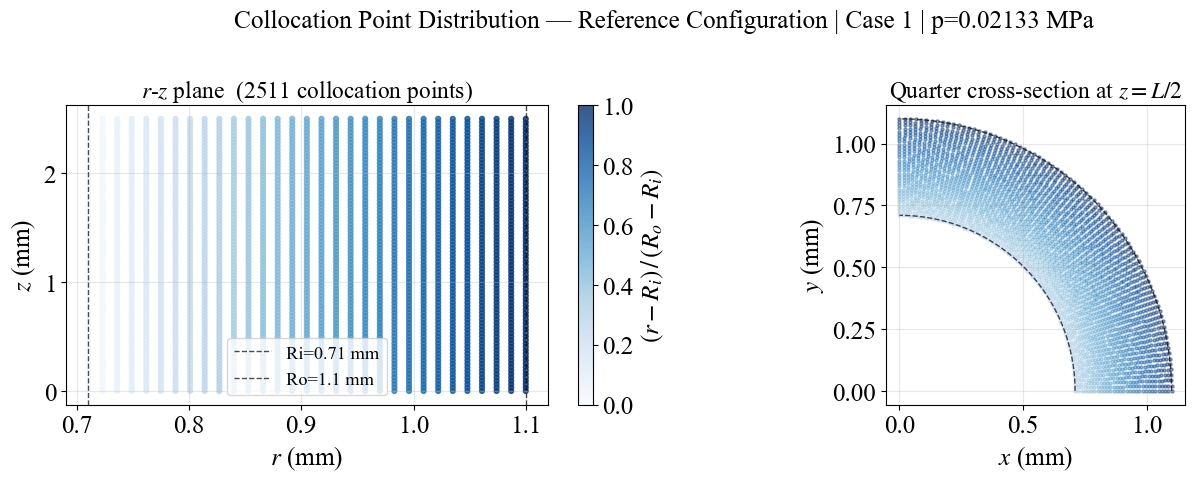

C:\Users\Administrator\AppData\Local\Temp\1\ipykernel_31364\98703949.py:191: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_loss.legend(fontsize=legend_fontsize)


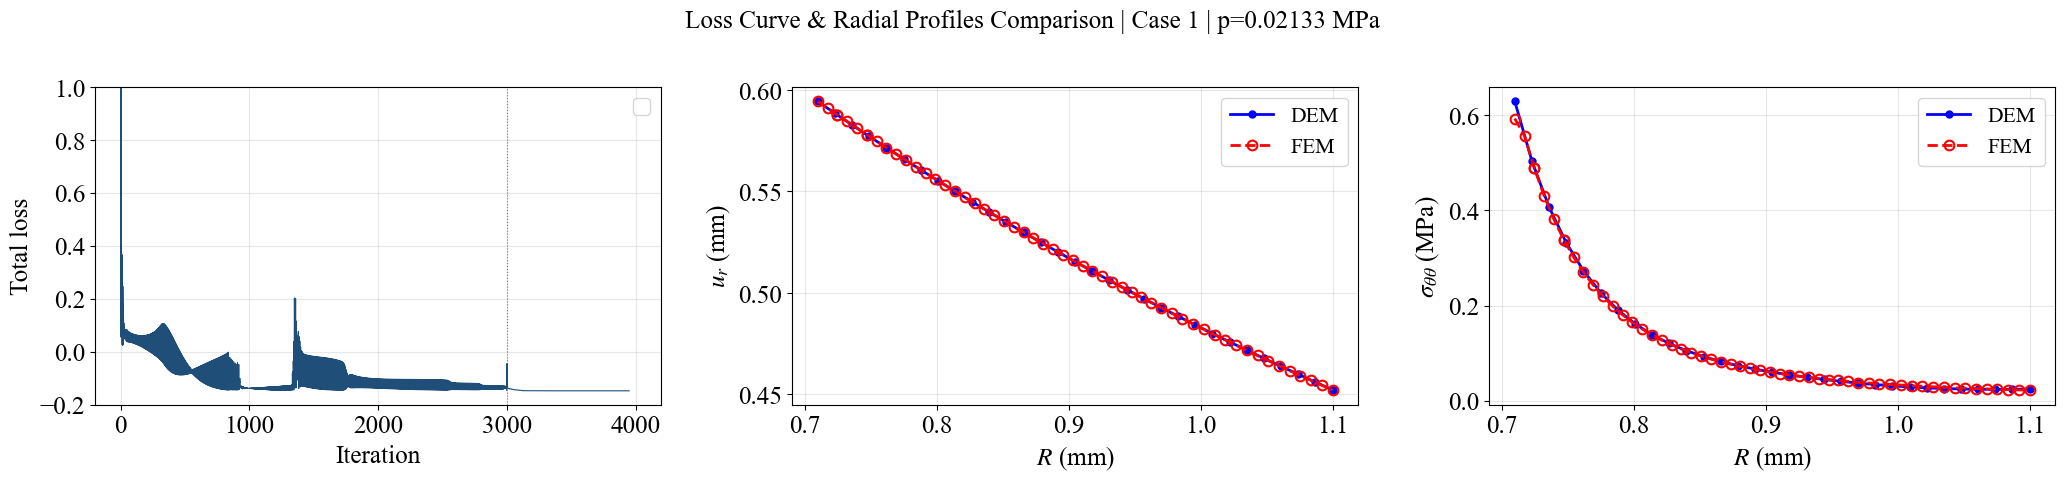

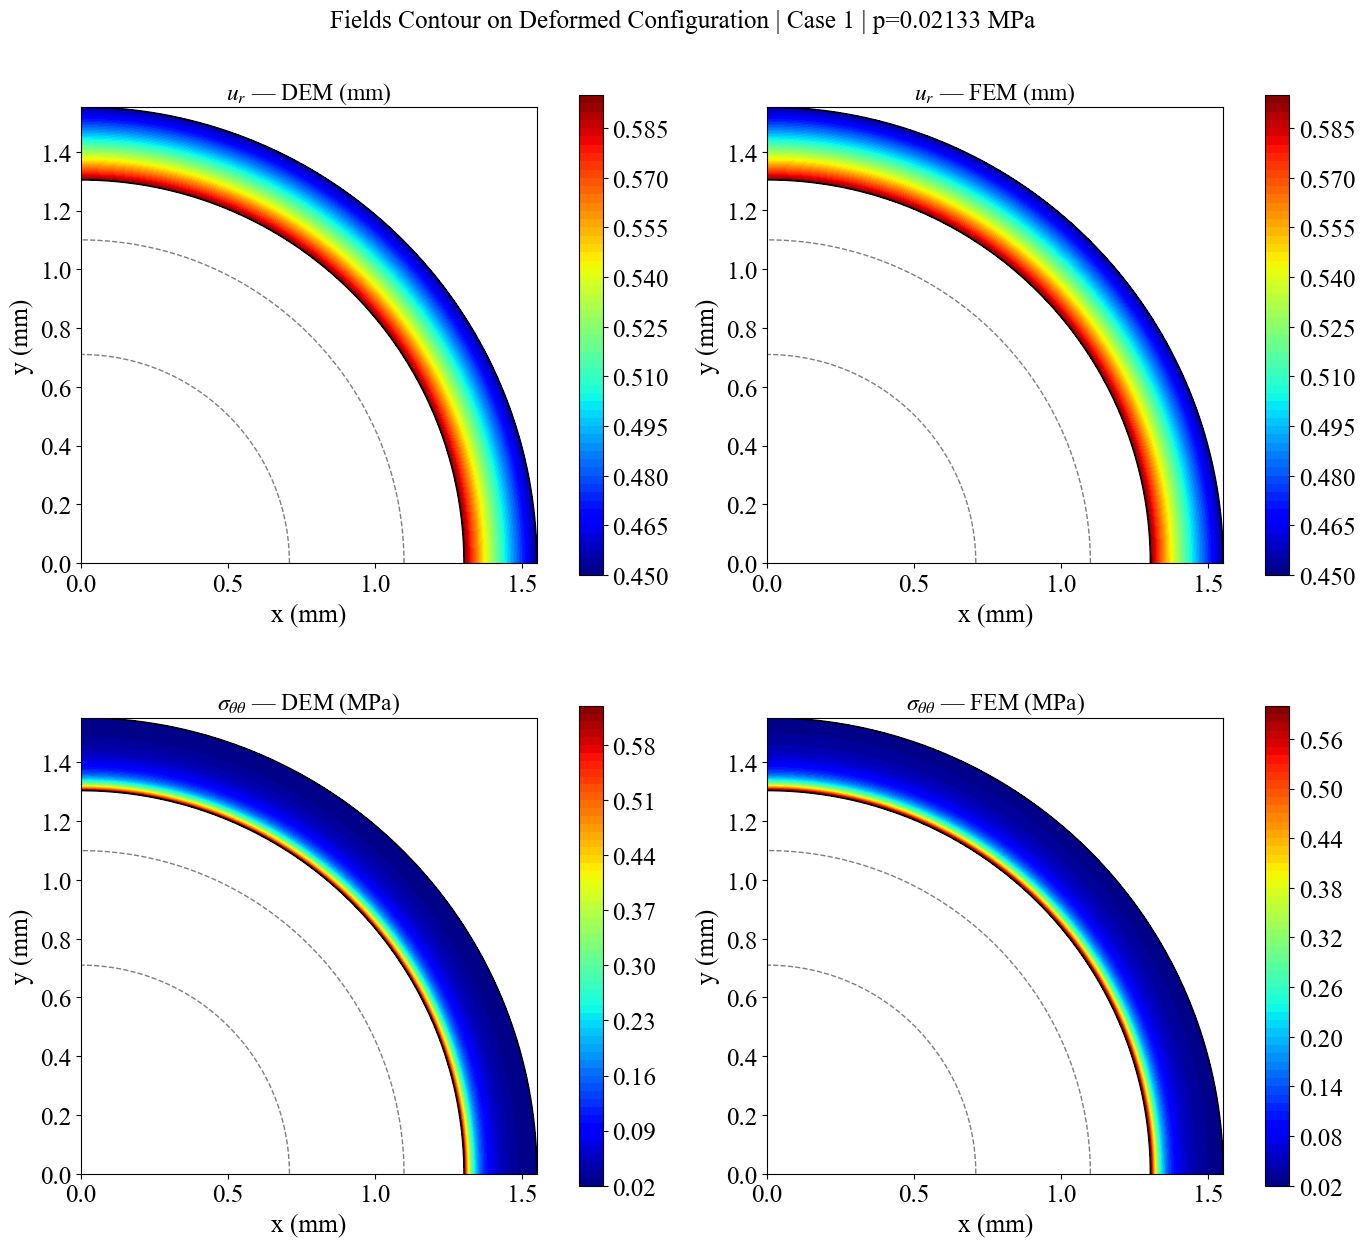

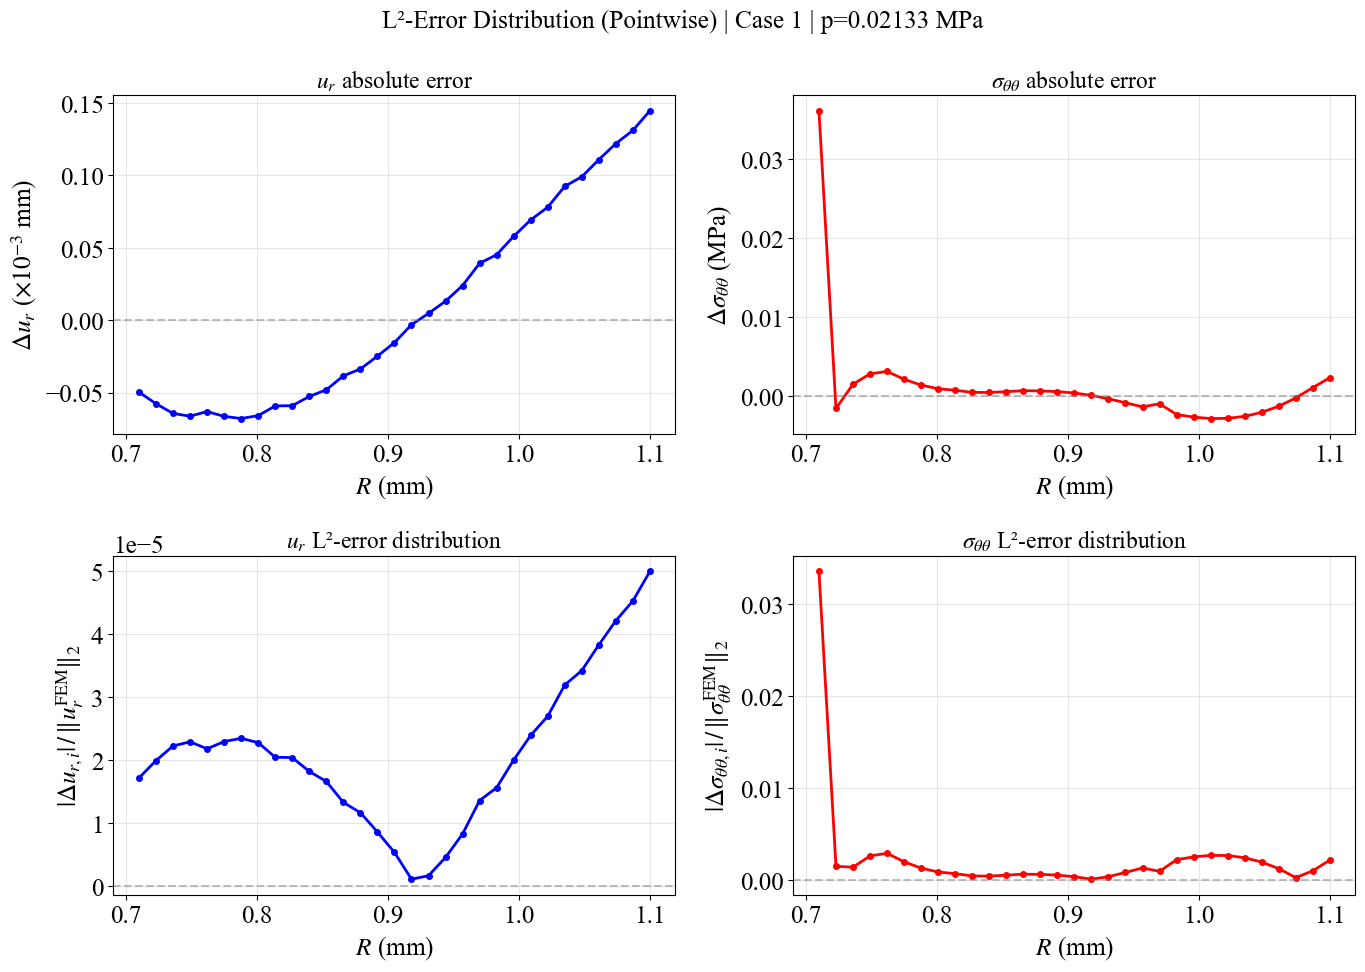

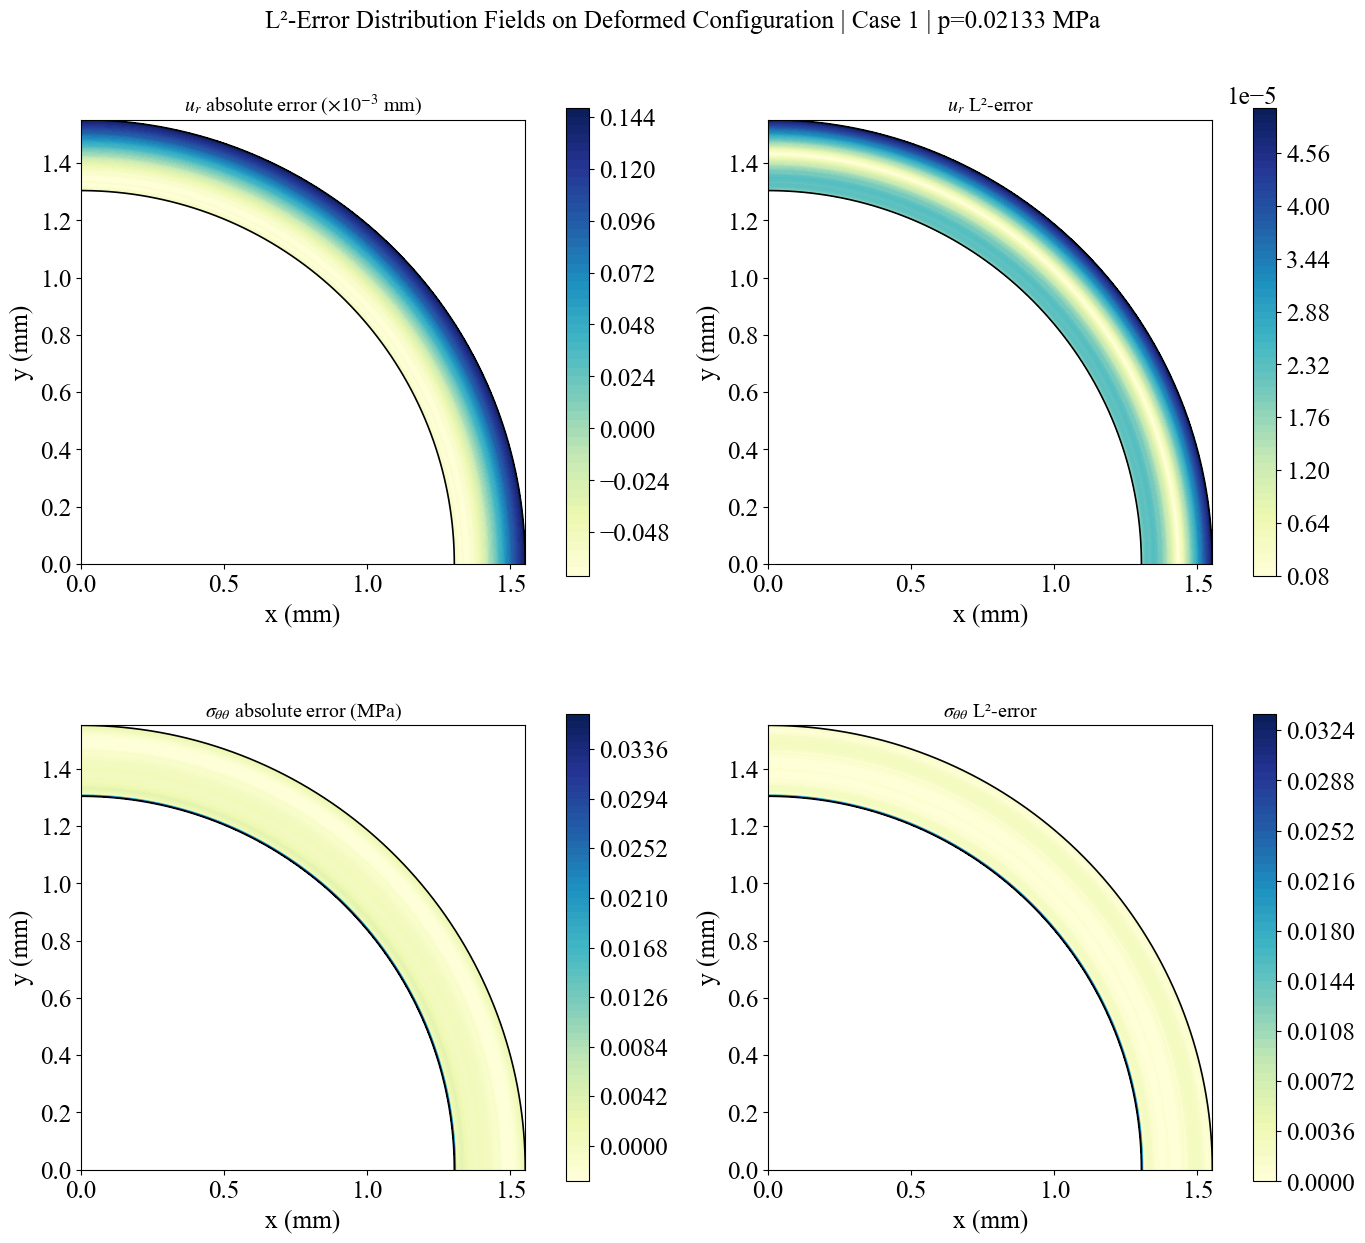


 Error summary | Case 1 | p=0.02133 MPa
 [displacement: mm | stress: MPa]
Quantity                    DEM          FEM   Abs. error L2-error dist. (%)
u_r (Ri)               0.594372     0.594423    -0.000051             0.002%
u_r (Ro)               0.452152     0.452006     0.000146             0.005%
sigma_tt (Ri)          0.628856     0.592754     0.036102             3.357%
sigma_tt (Ro)          0.024696     0.022388     0.002308             0.215%
-----------------------------------------------------------------
 Global relative L2 error:
  u_r       L2 error: 0.0134%
  sigma_tt  L2 error: 3.4642%



In [139]:
# ==============================================================================
# Case 1: DEM vs Abaqus FEM
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.interpolate import interp1d

# ========== Font size ==========
FONT_SCALE        = 1.30
BASE_FONTSIZE     = 14
tick_fontsize     = BASE_FONTSIZE * FONT_SCALE
label_fontsize    = BASE_FONTSIZE * FONT_SCALE
legend_fontsize   = 12 * FONT_SCALE
title_fontsize    = 13 * FONT_SCALE
suptitle_fontsize = 14 * FONT_SCALE
contour_title_fs  = 13 * FONT_SCALE

plt.rcParams['font.family']      = 'serif'
plt.rcParams['font.serif']       = ['Times New Roman']
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.size']        = BASE_FONTSIZE * FONT_SCALE
plt.rcParams['axes.titlesize']   = title_fontsize
plt.rcParams['axes.labelsize']   = label_fontsize
plt.rcParams['xtick.labelsize']  = tick_fontsize
plt.rcParams['ytick.labelsize']  = tick_fontsize
plt.rcParams['legend.fontsize']  = legend_fontsize

MPA_TO_KPA = 1.0

# ========== 0. DEM mid-section fields (Case 1) ==========
mid = nz // 2
ur_c1, uz_c1, r_mid, stt_c1, srr_c1, szz_c1 = visualize_results(
    net_c1, RZdata_c1, R_grid_c1, Z_grid_c1,
    energy_fn_c1, bc_fn_c1,
    params_single, a1_c1.cpu().numpy(), a2_c1.cpu().numpy(),
    case_title="Case 1", save_prefix="case1")

ur_dem_mid = ur_c1[:, mid]
stt_dem    = stt_c1 * MPA_TO_KPA

# ========== 1. Read Abaqus rpt ==========
rpt_path = r"E:\QL\DEM_HGO\codes\new\singlelayer-pressure.rpt"

fem_data = []
with open(rpt_path, 'r') as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) == 10:
            try:
                fem_data.append([float(x) for x in parts])
            except ValueError:
                pass

fem_data = np.array(fem_data)
if fem_data.size == 0:
    raise RuntimeError(f"Could not parse 10 valid columns from {rpt_path}.")

print(f"Abaqus data loaded: {fem_data.shape[0]} nodes.")

r_fem_current = fem_data[:, 1]
z_fem         = fem_data[:, 3]
ur_fem        = fem_data[:, 4]
s22_fem       = fem_data[:, 8] * MPA_TO_KPA
r_fem_ref     = r_fem_current - ur_fem

z_unique  = np.unique(np.round(z_fem, 5))
z_mid_val = z_unique[np.argmin(np.abs(z_unique - 0.0))]
mid_mask  = np.abs(z_fem - z_mid_val) < 1e-3

r_fem_mid   = r_fem_ref[mid_mask]
ur_fem_mid  = ur_fem[mid_mask]
stt_fem_mid = s22_fem[mid_mask]

idx_s = np.argsort(r_fem_mid)
r_fem_mid   = r_fem_mid[idx_s]
ur_fem_mid  = ur_fem_mid[idx_s]
stt_fem_mid = stt_fem_mid[idx_s]

_, uniq_idx = np.unique(np.round(r_fem_mid, 5), return_index=True)
r_fem_mid   = r_fem_mid[uniq_idx]
ur_fem_mid  = ur_fem_mid[uniq_idx]
stt_fem_mid = stt_fem_mid[uniq_idx]

r_fem_def_mid = r_fem_mid + ur_fem_mid

# ========== 2. Coordinate axes ==========
r_dem_mid_axis = r_mid
r_dem_def_axis = r_mid + ur_dem_mid
r_fem_mid_axis = r_fem_mid
r_fem_def_axis = r_fem_def_mid

Ri_dem_def_val, Ro_dem_def_val = r_dem_def_axis[0],  r_dem_def_axis[-1]
Ri_fem_def_val, Ro_fem_def_val = r_fem_def_axis[0],  r_fem_def_axis[-1]

title_base = f"Case 1 | p={p_max} MPa"

# ========== 3. Interpolation ==========
f_ur_fem       = interp1d(r_fem_mid_axis, ur_fem_mid,  kind='linear', fill_value='extrapolate')
f_stt_fem      = interp1d(r_fem_mid_axis, stt_fem_mid, kind='linear', fill_value='extrapolate')
ur_fem_interp  = f_ur_fem(r_dem_mid_axis)
stt_fem_interp = f_stt_fem(r_dem_mid_axis)

# ========== 4. Error computation ==========
err_ur_abs  = ur_dem_mid - ur_fem_interp
err_stt_abs = stt_dem    - stt_fem_interp

ur_L2_norm  = np.linalg.norm(ur_fem_interp)
stt_L2_norm = np.linalg.norm(stt_fem_interp)

err_ur_L2dist  = np.abs(err_ur_abs)  / ur_L2_norm
err_stt_L2dist = np.abs(err_stt_abs) / stt_L2_norm

err_ur_L2  = np.linalg.norm(err_ur_abs)  / ur_L2_norm
err_stt_L2 = np.linalg.norm(err_stt_abs) / stt_L2_norm

# ========== Group 0: collocation point distribution ==========
# Single-layer: all points share the same material; colour by r to show
# radial density, and a separate quarter cross-section view.
pts   = RZdata_c1.cpu().numpy()   # shape (N, 2): [r, z]
r_pts = pts[:, 0]
z_pts = pts[:, 1]

fig0, axes0 = plt.subplots(1, 2, figsize=(14, 5))
fig0.suptitle(
    f"Collocation Point Distribution — Reference Configuration | {title_base}",
    fontsize=suptitle_fontsize)

# Left: r-z plane — colour by normalised radial position
r_norm = (r_pts - Ri) / (Ro - Ri)
sc = axes0[0].scatter(r_pts, z_pts, c=r_norm, cmap='Blues',
                      s=12, alpha=0.8, vmin=0, vmax=1)
fig0.colorbar(sc, ax=axes0[0], label='$(r - R_i)\\,/\\,(R_o - R_i)$')
for rv, lab in [(Ri, f'Ri={Ri} mm'), (Ro, f'Ro={Ro} mm')]:
    axes0[0].axvline(x=rv, color='k', ls='--', lw=1.0, alpha=0.7, label=lab)
axes0[0].set_xlabel('$r$ (mm)')
axes0[0].set_ylabel('$z$ (mm)')
axes0[0].set_title(f'$r$-$z$ plane  ({len(r_pts)} collocation points)')
axes0[0].legend(fontsize=legend_fontsize * 0.85)
axes0[0].grid(True, alpha=0.3)

# Right: quarter cross-section at z = L/2
dz_tol  = (L / (nz - 1)) * 0.6
th_vis  = np.linspace(0, np.pi / 2, 80)
r_mid_pts = r_pts[np.abs(z_pts - L / 2) < dz_tol]
r_norm_mid = (r_mid_pts - Ri) / (Ro - Ri)

for ri, rn in zip(r_mid_pts, r_norm_mid):
    c = plt.cm.Blues(0.3 + 0.7 * rn)
    axes0[1].scatter(ri * np.cos(th_vis), ri * np.sin(th_vis),
                     color=c, s=5, alpha=0.45)

th_arc0 = np.linspace(0, np.pi / 2, 200)
for rv in [Ri, Ro]:
    axes0[1].plot(rv * np.cos(th_arc0), rv * np.sin(th_arc0),
                  'k--', lw=1.0, alpha=0.7)

axes0[1].set_xlabel('$x$ (mm)')
axes0[1].set_ylabel('$y$ (mm)')
axes0[1].set_title('Quarter cross-section at $z = L/2$')
axes0[1].set_aspect('equal')
axes0[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./pth/case1_collocation_points.png', dpi=300, bbox_inches='tight')
plt.show()

# ========== Group 1: Loss + radial 1-D profiles (1 row × 3 cols) ==========
fig1, axes1 = plt.subplots(1, 3, figsize=(21, 5))
fig1.suptitle(f"Loss Curve & Radial Profiles Comparison | {title_base}",
              fontsize=suptitle_fontsize)

# ---- Left: Case 1 loss curve (raw, no smoothing) ----
ax_loss = axes1[0]
hist    = all_loss_history_c1[0]
Pi      = np.array([r[2] for r in hist], float)
opt     = [r[0] for r in hist]
split   = next((i for i, o in enumerate(opt) if o == 'lbfgs'), len(opt))
x       = np.arange(len(Pi))

ax_loss.plot(x[:split], Pi[:split], color='#1f4e79', lw=0.8)
ax_loss.plot(x[split:], Pi[split:], color='#1f4e79', lw=0.8)
ax_loss.axvline(split, color='#1f4e79', lw=0.8, ls=':', alpha=0.7
               )
ax_loss.set_xlim(-200, 4200)
ax_loss.set_ylim(-0.2, 1)
ax_loss.set_xlabel('Iteration', fontsize=label_fontsize)
ax_loss.set_ylabel('Total loss', fontsize=label_fontsize)
# ax_loss.set_title('Loss convergence', fontsize=title_fontsize)
ax_loss.tick_params(axis='both', labelsize=tick_fontsize)
ax_loss.legend(fontsize=legend_fontsize)
ax_loss.grid(True, alpha=0.3)

# ---- Middle: u_r comparison ----
axes1[1].plot(r_dem_mid_axis, ur_dem_mid, 'b-o',  ms=5, lw=2, label='DEM')
axes1[1].plot(r_fem_mid_axis, ur_fem_mid, 'r--o', ms=7, lw=2,
              mfc='none', mew=1.5, label='FEM')
axes1[1].set_xlabel('$R$ (mm)', fontsize=label_fontsize)
axes1[1].set_ylabel('$u_r$ (mm)', fontsize=label_fontsize)
# axes1[1].set_title('Radial displacement $u_r$', fontsize=title_fontsize)
axes1[1].tick_params(axis='both', labelsize=tick_fontsize)
axes1[1].legend(fontsize=legend_fontsize)
axes1[1].grid(True, alpha=0.3)

# ---- Right: σ_θθ comparison ----
axes1[2].plot(r_dem_mid_axis, stt_dem,     'b-o',  ms=5, lw=2, label='DEM')
axes1[2].plot(r_fem_mid_axis, stt_fem_mid, 'r--o', ms=7, lw=2,
              mfc='none', mew=1.5, label='FEM')
axes1[2].set_xlabel('$R$ (mm)', fontsize=label_fontsize)
axes1[2].set_ylabel(r'$\sigma_{\theta\theta}$ (MPa)', fontsize=label_fontsize)
# axes1[2].set_title(r'Hoop stress $\sigma_{\theta\theta}$', fontsize=title_fontsize)
axes1[2].tick_params(axis='both', labelsize=tick_fontsize)
axes1[2].legend(fontsize=legend_fontsize)
axes1[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./pth/case1_loss_and_radial.png', dpi=300, bbox_inches='tight')
plt.show()


# ========== Figure 2: Quarter-annulus contour maps ==========
n_theta = 91
theta_q = np.linspace(0, np.pi / 2, n_theta)
th_arc  = np.linspace(0, np.pi / 2, 150)

Rq_dem_def, Tq_dem = np.meshgrid(r_dem_def_axis, theta_q, indexing='ij')
Xq_dem_def = Rq_dem_def * np.cos(Tq_dem)
Yq_dem_def = Rq_dem_def * np.sin(Tq_dem)

Rq_fem_def, Tq_fem = np.meshgrid(r_fem_def_axis, theta_q, indexing='ij')
Xq_fem_def = Rq_fem_def * np.cos(Tq_fem)
Yq_fem_def = Rq_fem_def * np.sin(Tq_fem)

ur_dem_2d  = np.tile(ur_dem_mid.reshape(-1, 1),  (1, n_theta))
stt_dem_2d = np.tile(stt_dem.reshape(-1, 1),     (1, n_theta))
ur_fem_2d  = np.tile(ur_fem_mid.reshape(-1, 1),  (1, n_theta))
stt_fem_2d = np.tile(stt_fem_mid.reshape(-1, 1), (1, n_theta))

fig2, axes2 = plt.subplots(2, 2, figsize=(14, 13))
fig2.suptitle(f"Fields Contour on Deformed Configuration | {title_base}",
              fontsize=suptitle_fontsize)

plot_configs_fig2 = [
    (axes2[0, 0], Xq_dem_def, Yq_dem_def, ur_dem_2d,
     '$u_r$ — DEM (mm)',                               Ri_dem_def_val, Ro_dem_def_val),
    (axes2[0, 1], Xq_fem_def, Yq_fem_def, ur_fem_2d,
     '$u_r$ — FEM (mm)',                               Ri_fem_def_val, Ro_fem_def_val),
    (axes2[1, 0], Xq_dem_def, Yq_dem_def, stt_dem_2d,
     r'$\sigma_{\theta\theta}$ — DEM (MPa)',           Ri_dem_def_val, Ro_dem_def_val),
    (axes2[1, 1], Xq_fem_def, Yq_fem_def, stt_fem_2d,
     r'$\sigma_{\theta\theta}$ — FEM (MPa)',           Ri_fem_def_val, Ro_fem_def_val),
]

for ax, xp, yp, data, name, r_in_def, r_out_def in plot_configs_fig2:
    cs = ax.contourf(xp, yp, data, 64, cmap='jet')
    fig2.colorbar(cs, ax=ax, fraction=0.046, pad=0.08)
    ax.set_title(name, fontsize=contour_title_fs)
    ax.plot(r_in_def  * np.cos(th_arc), r_in_def  * np.sin(th_arc), 'k-',  lw=1.2)
    ax.plot(r_out_def * np.cos(th_arc), r_out_def * np.sin(th_arc), 'k-',  lw=1.2)
    ax.plot(r_dem_mid_axis[0]  * np.cos(th_arc),
            r_dem_mid_axis[0]  * np.sin(th_arc), 'k--', lw=1.0, alpha=0.5)
    ax.plot(r_dem_mid_axis[-1] * np.cos(th_arc),
            r_dem_mid_axis[-1] * np.sin(th_arc), 'k--', lw=1.0, alpha=0.5)
    ax.set_xlabel('x (mm)')
    ax.set_ylabel('y (mm)')
    ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('./pth/case1_dem_vs_fem_contour.png', dpi=300, bbox_inches='tight')
plt.show()

# ========== Figure 3: L2-error distribution profiles ==========
fig3, axes3 = plt.subplots(2, 2, figsize=(14, 10))
fig3.suptitle(f"L²-Error Distribution (Pointwise) | {title_base}",
              fontsize=suptitle_fontsize)

error_profile_configs = [
    (axes3[0, 0], err_ur_abs * 1000, 'b',
     r'$\Delta u_r$ ($\times 10^{-3}$ mm)',
     r'$u_r$ absolute error'),
    (axes3[0, 1], err_stt_abs,       'r',
     r'$\Delta\sigma_{\theta\theta}$ (MPa)',
     r'$\sigma_{\theta\theta}$ absolute error'),
    (axes3[1, 0], err_ur_L2dist,     'b',
     r'$|\Delta u_{r,i}|\,/\,\|u_r^{\mathrm{FEM}}\|_2$',
     r'$u_r$ L²-error distribution'),
    (axes3[1, 1], err_stt_L2dist,    'r',
     r'$|\Delta\sigma_{\theta\theta,i}|\,/\,\|\sigma_{\theta\theta}^{\mathrm{FEM}}\|_2$',
     r'$\sigma_{\theta\theta}$ L²-error distribution'),
]

for ax, ydata, color, ylabel, title_str in error_profile_configs:
    ax.plot(r_dem_mid_axis, ydata, f'{color}-o', ms=4, lw=2)
    ax.axhline(y=0, color='gray', ls='--', alpha=0.5)
    ax.set_xlabel('$R$ (mm)')
    ax.set_ylabel(ylabel)
    ax.set_title(title_str)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./pth/case1_error_profiles.png', dpi=300, bbox_inches='tight')
plt.show()

# ========== Figure 4: L2-error distribution contour maps ==========
err_ur_abs_2d  = np.tile((err_ur_abs * 1000)[:, None], (1, n_theta))
err_stt_abs_2d = np.tile(err_stt_abs[:, None],         (1, n_theta))
err_ur_L2d_2d  = np.tile(err_ur_L2dist[:, None],       (1, n_theta))
err_stt_L2d_2d = np.tile(err_stt_L2dist[:, None],      (1, n_theta))

fig4, axes4 = plt.subplots(2, 2, figsize=(14, 13))
fig4.suptitle(f"L²-Error Distribution Fields on Deformed Configuration | {title_base}",
              fontsize=suptitle_fontsize)

plot_configs_fig4 = [
    (axes4[0, 0], err_ur_abs_2d,
     r'$u_r$ absolute error ($\times 10^{-3}$ mm)'),
    (axes4[0, 1], err_ur_L2d_2d,
     r'$u_r$ L²-error'),
    (axes4[1, 0], err_stt_abs_2d,
     r'$\sigma_{\theta\theta}$ absolute error (MPa)'),
    (axes4[1, 1], err_stt_L2d_2d,
     r'$\sigma_{\theta\theta}$ L²-error'),
]

for ax, data, name in plot_configs_fig4:
    cs = ax.contourf(Xq_dem_def, Yq_dem_def, data, 64, cmap='YlGnBu')
    fig4.colorbar(cs, ax=ax, fraction=0.046, pad=0.08)
    ax.set_title(name, fontsize=contour_title_fs * 0.85)
    ax.plot(Ri_dem_def_val * np.cos(th_arc),
            Ri_dem_def_val * np.sin(th_arc), 'k-', lw=1.2)
    ax.plot(Ro_dem_def_val * np.cos(th_arc),
            Ro_dem_def_val * np.sin(th_arc), 'k-', lw=1.2)
    ax.plot([0, 0], [Ri_dem_def_val, Ro_dem_def_val], 'k-', lw=1.2)
    ax.set_xlabel('x (mm)')
    ax.set_ylabel('y (mm)')
    ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('./pth/case1_error_contours.png', dpi=300, bbox_inches='tight')
plt.show()

# ========== Error statistics ==========
print(f"\n{'='*65}")
print(f" Error summary | {title_base}")
print(f" [displacement: mm | stress: MPa]")
print(f"{'='*65}")
print(f"{'Quantity':<18} {'DEM':>12} {'FEM':>12} {'Abs. error':>12} {'L2-error dist. (%)':>18}")
for name, op_v, fem_v, l2_norm in [
    ('u_r (Ri)',      ur_dem_mid[0],  ur_fem_mid[0],  ur_L2_norm),
    ('u_r (Ro)',      ur_dem_mid[-1], ur_fem_mid[-1], ur_L2_norm),
    ('sigma_tt (Ri)', stt_dem[0],     stt_fem_mid[0], stt_L2_norm),
    ('sigma_tt (Ro)', stt_dem[-1],    stt_fem_mid[-1],stt_L2_norm),
]:
    abs_e = op_v - fem_v
    l2d   = (np.abs(abs_e) / l2_norm) * 100
    print(f"{name:<18} {op_v:>12.6f} {fem_v:>12.6f} {abs_e:>12.6f} {l2d:>17.3f}%")
print(f"{'-'*65}")
print(f" Global relative L2 error:")
print(f"  u_r       L2 error: {err_ur_L2 *100:.4f}%")
print(f"  sigma_tt  L2 error: {err_stt_L2*100:.4f}%")
print(f"{'='*65}\n")

In [17]:
# =================== Case 1: Export loss data to CSV ===================
import csv
import os

os.makedirs('./pth', exist_ok=True)
csv_path = './pth/case1_loss_history.csv'

with open(csv_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['step', 'p_MPa', 'optimizer', 'iteration', 'loss'])
    for si, loss_hist in enumerate(all_loss_history_c1):
        p_val = results_c1[si]['p']
        for r in loss_hist:
            writer.writerow([si + 1, p_val, r[0], r[1], r[2]])

print(f"saved: {csv_path}")

import pandas as pd
df = pd.read_csv(csv_path)
print(df.head())
print(f"total rows: {len(df)}")

saved: ./pth/case1_loss_history.csv
   step    p_MPa optimizer  iteration       loss
0     1  0.02133      adam          0  20.889432
1     1  0.02133      adam          1   0.111521
2     1  0.02133      adam          2   0.055033
3     1  0.02133      adam          3   2.580383
4     1  0.02133      adam          4   1.644831
total rows: 3951


---
## Case 2: Bi-layer Cylinder + Inner Pressure

Media (Ri->Rm): gamma=29, k1=0.64, k2=3.54

Adventitia (Rm->Ro): gamma=62, k1=0.47, k2=22.10

In [18]:
# =================== Case 2: Prepare===================
print("="*60)
print("Case 2: Double-layer cylinder + internal pressure")
print("="*60)

RZdata_c2, R_grid_c2, Z_grid_c2, r_nodes_c2 = create_geometry_rz(Ri, Ro, L, nr, nz)
dr_c2 = (Ro - Ri) / (nr - 1)
dz_c2 = L / (nz - 1)
vol_weights_c2  = simpson_weights_2d_cyl(nr, nz, dr_c2, dz_c2, r_nodes_c2)
surf_weights_c2 = simpson_weights_1d_cyl_surface(nz, dz_c2, Ri)
mask_ri_c2 = RZdata_c2[:, 0] < (Ri + eps)

# Material Partition
mask_media = RZdata_c2[:, 0] < Rm
mask_adv   = RZdata_c2[:, 0] >= Rm
print(f"Media points: {mask_media.sum().item()}, Adventitia: {mask_adv.sum().item()}")

a1_media, a2_media = get_fiber_directions(params_media['gamma'])
a1_adv,   a2_adv   = get_fiber_directions(params_adventitia['gamma'])
net_c2 = DEM_Network(Ri, Ro, L)

def energy_fn_c2(F):
    N = F.shape[0]
    W = torch.zeros(N, dtype=dtype, device=device)
    J = torch.zeros(N, dtype=dtype, device=device)
    if mask_media.any():
        W_m, J_m = compute_hgo_energy(F[mask_media], params_media, a1_media, a2_media)
        W[mask_media] = W_m
        J[mask_media] = J_m
    if mask_adv.any():
        W_a, J_a = compute_hgo_energy(F[mask_adv], params_adventitia, a1_adv, a2_adv)
        W[mask_adv] = W_a
        J[mask_adv] = J_a
    return W, J

def bc_fn_c2(rz, y_hat):
    return apply_hard_BC_pressure_only(rz, y_hat, L)

p_steps_c2 = np.linspace(p_max / n_steps, p_max, n_steps)
print(f"Pressure steps: {p_steps_c2}")

Case 2: Double-layer cylinder + internal pressure
Media points: 1620, Adventitia: 891
Pressure steps: [0.0053325 0.010665  0.0159975 0.02133  ]


In [19]:
# =================== Case 2: Solver (One shot No tarnsfer learning) ===================
results_c2 = []
all_loss_history_c2 = []
t0 = time.time()

p_val = p_max  
print(f"--- One-shot: p = {p_val:.4f} MPa ---")

loss, loss_hist = solve_one_step(
    net_c2, RZdata_c2, vol_weights_c2, surf_weights_c2,
    mask_ri_c2, p_val, energy_fn_c2, bc_fn_c2,
    adam_epochs=3000, lbfgs_epochs=800)

results_c2.append({'step': 1, 'p': p_val, 'loss': loss})
all_loss_history_c2.append(loss_hist)

t_total = time.time() - t0
print(f"\nCase 2 total time: {t_total:.0f} s ({t_total/60:.1f} min)")
os.makedirs('./pth', exist_ok=True)
torch.save(net_c2.state_dict(), './pth/case2_dem.pt')


--- One-shot: p = 0.0213 MPa ---
    Adam final: -1.499320e-01  |  L-BFGS final: -1.538488e-01

Case 2 total time: 93 s (1.5 min)


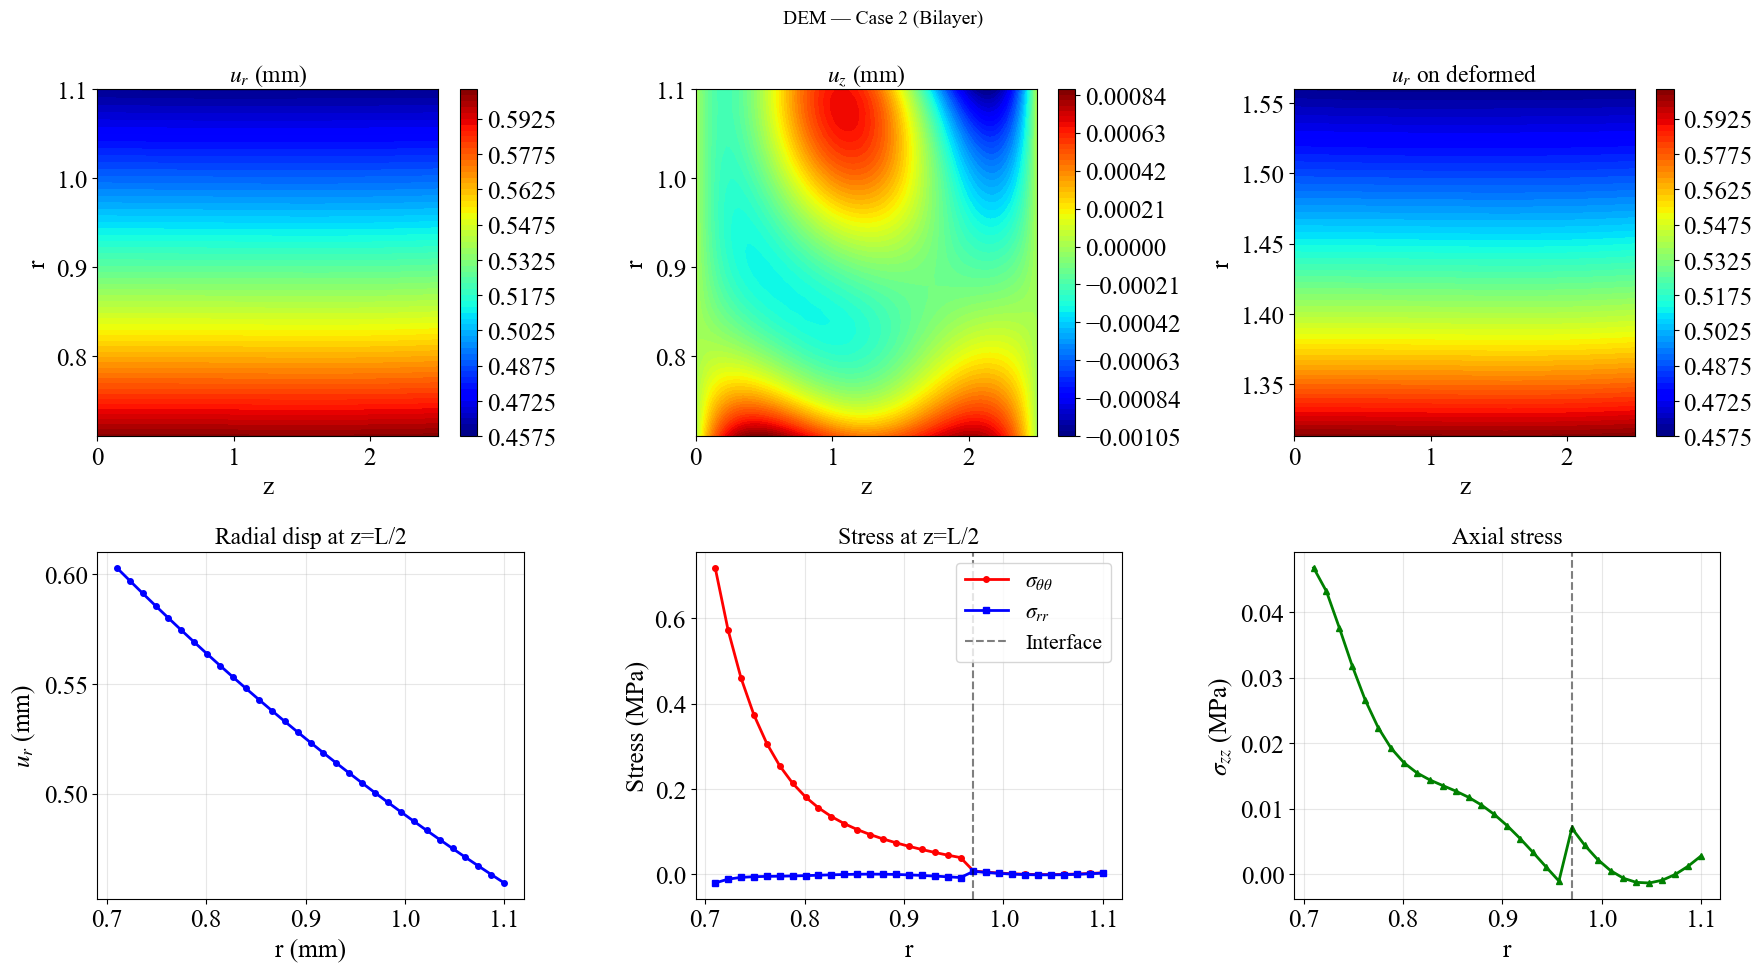

In [20]:
mid = nz // 2
def params_stress_c2(r_val):
    if r_val < Rm:
        return params_media, a1_media.cpu().numpy(), a2_media.cpu().numpy()
    else:
        return params_adventitia, a1_adv.cpu().numpy(), a2_adv.cpu().numpy()
ur_c2, uz_c2, r_mid, stt_c2, srr_c2, szz_c2 = visualize_results(
    net_c2, RZdata_c2, R_grid_c2, Z_grid_c2,
    energy_fn_c2, bc_fn_c2, 
    params_stress_c2, None, None, 
    case_title="Case 2 (Bilayer)", save_prefix="case2",
    interface_r=Rm
)
ur_mid_vals = ur_c2[:, mid]

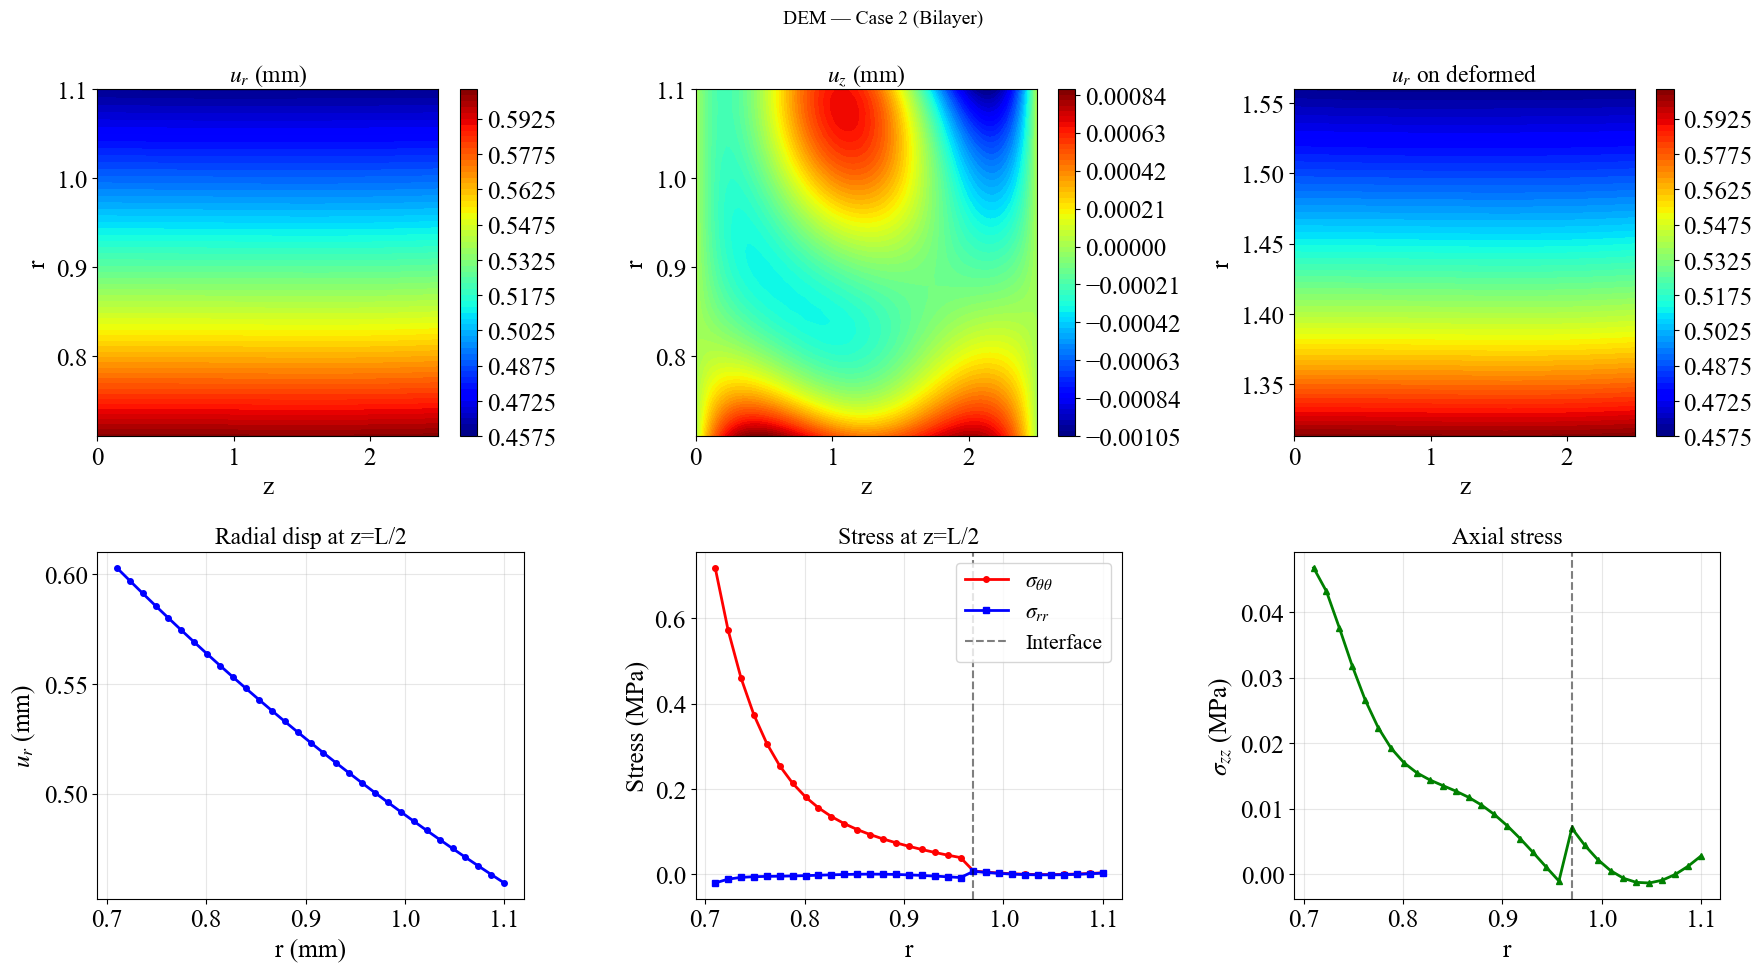

Abaqus FEM data loaded: 191520 nodes.
Interface radius - undeformed: R = 0.9700 mm
   deformed DEM: R_def = 1.4704 mm
   deformed FEM: R_def = 1.4703 mm


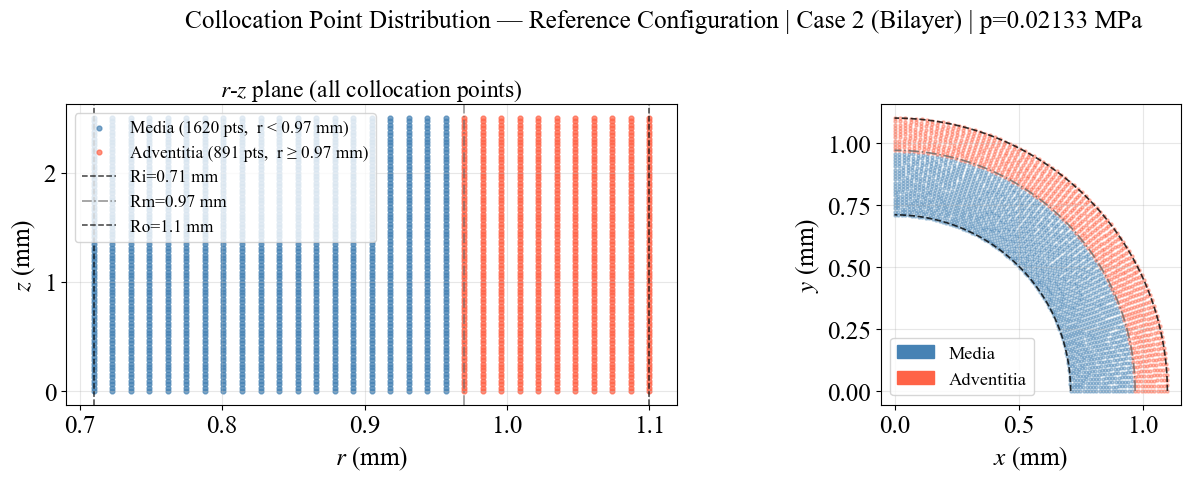

C:\Users\Administrator\AppData\Local\Temp\1\ipykernel_31364\3200921020.py:244: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_loss.legend(fontsize=legend_fontsize)


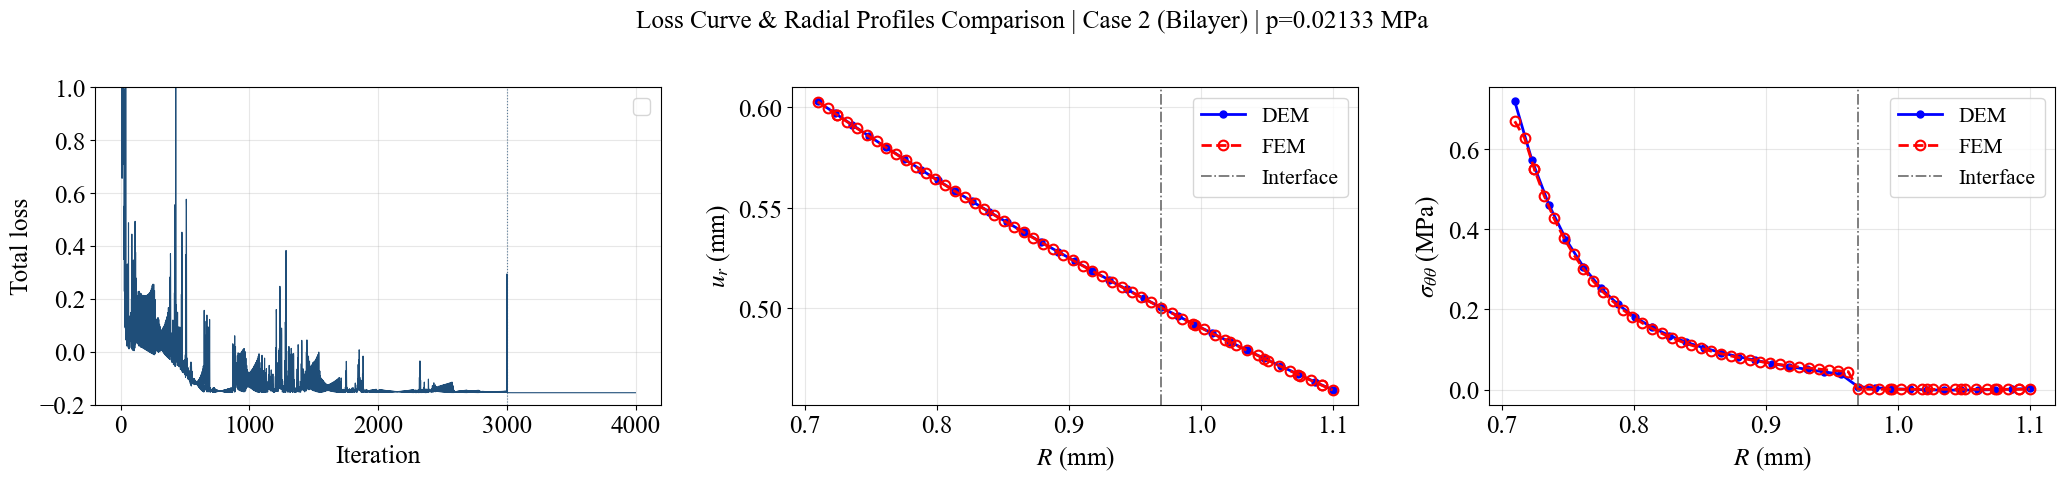

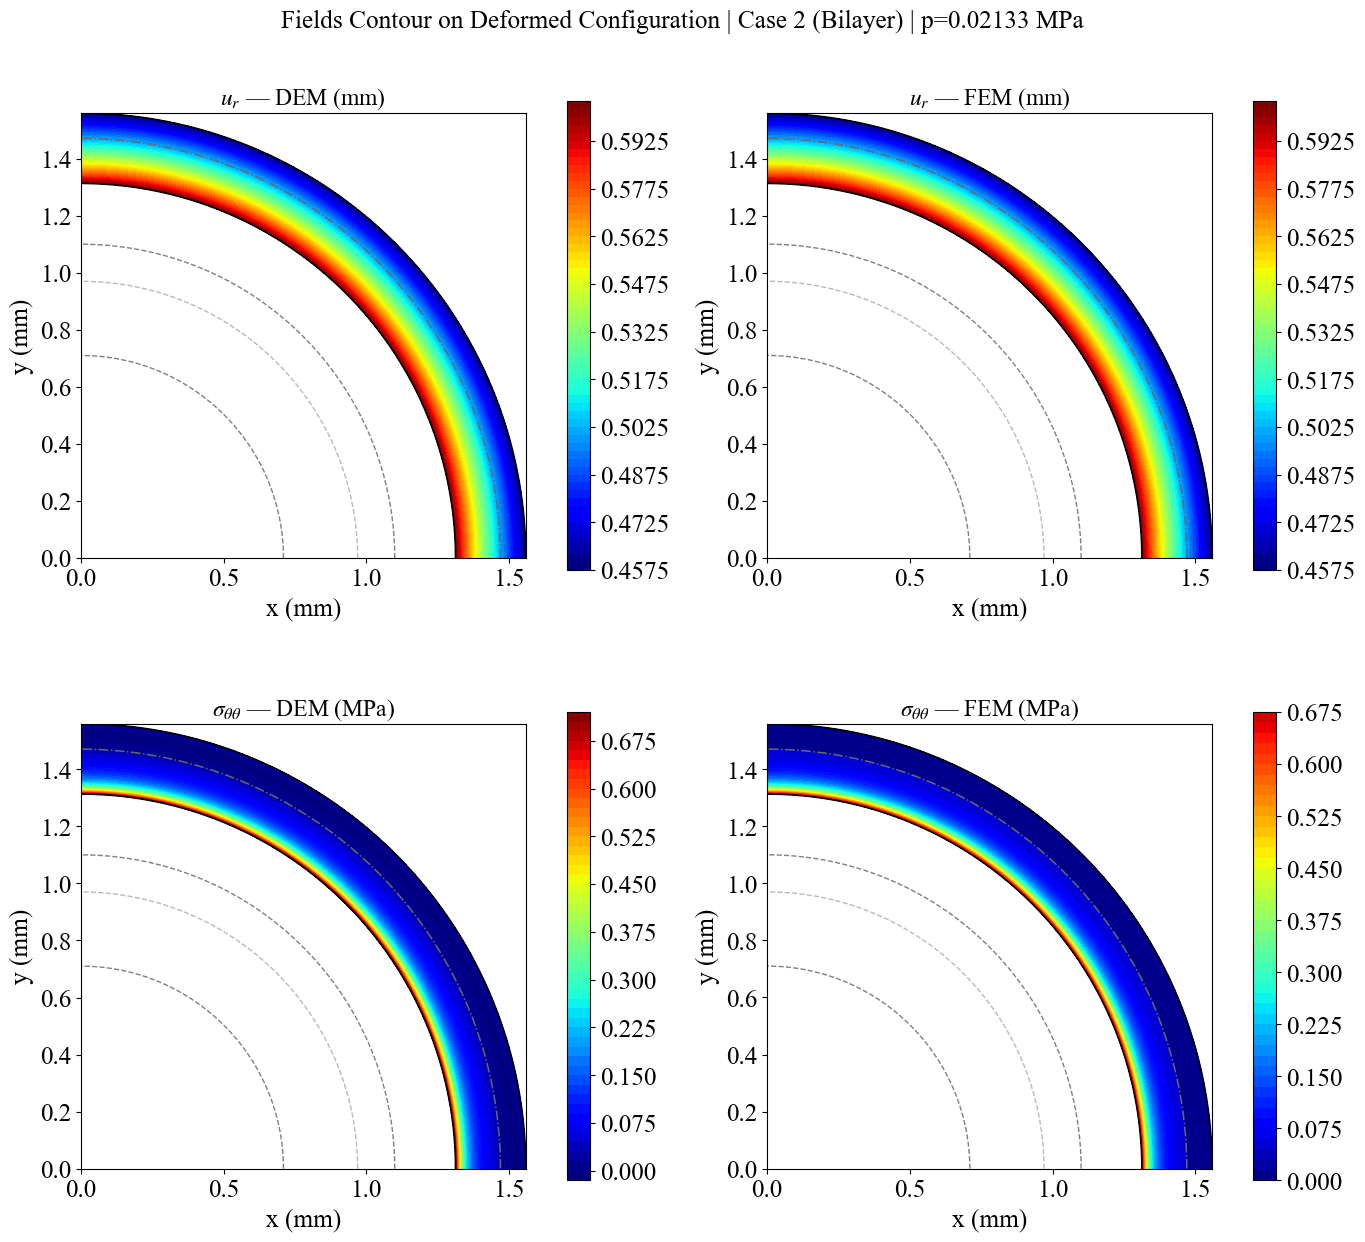

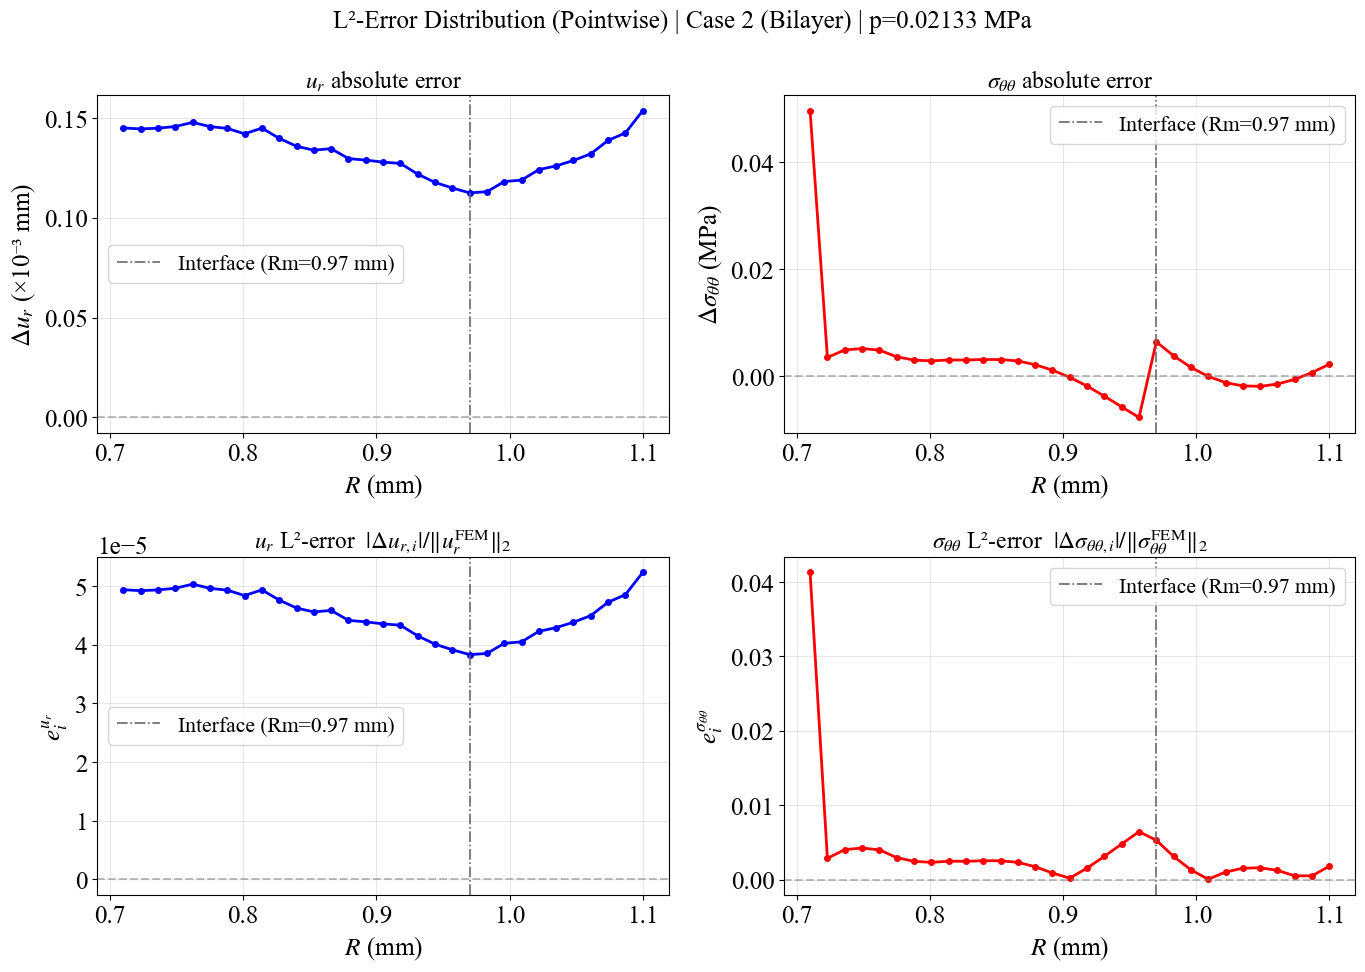

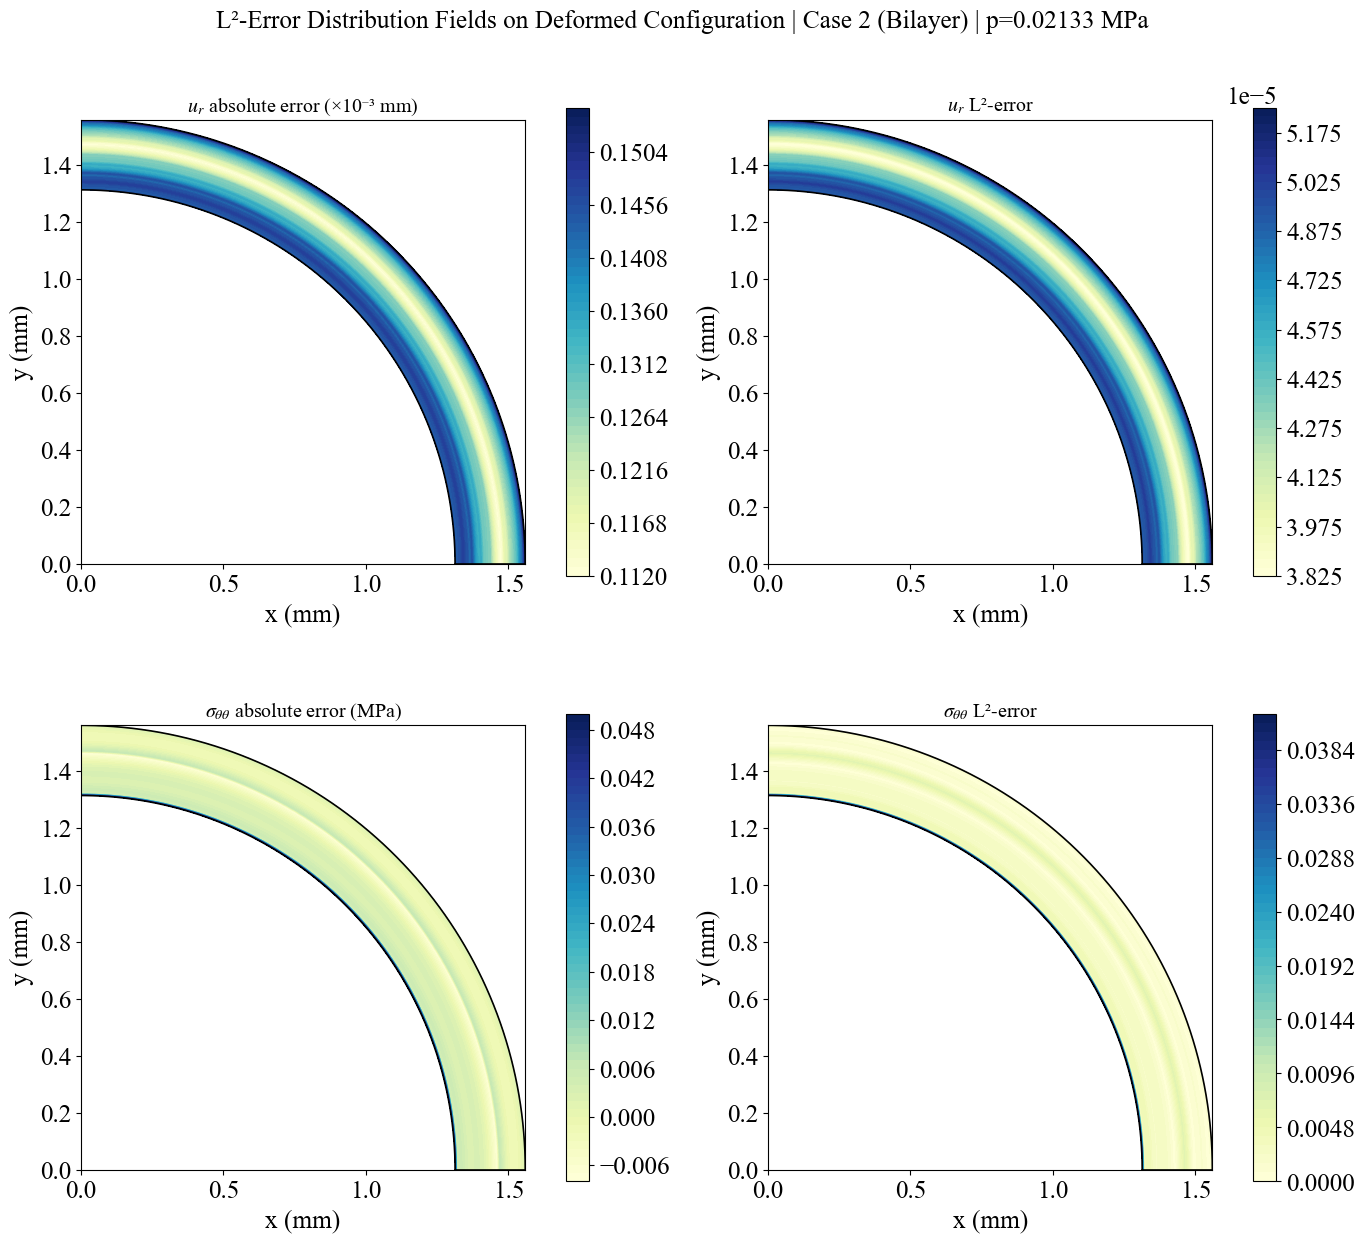


 Error summary | Case 2 (Bilayer) | p=0.02133 MPa
 [displacement: mm | stress: MPa]
Quantity                    DEM          FEM   Abs. error L2-error dist. (%)
u_r (Ri)               0.603018     0.602875     0.000143             0.005%
u_r (Ro)               0.459276     0.459124     0.000152             0.005%
sigma_tt (Ri)          0.718950     0.669398     0.049552             4.124%
sigma_tt (Ro)          0.002893     0.000686     0.002207             0.184%
-----------------------------------------------------------------
 Global relative L2 error:
  u_r       L2 error: 0.0253%
  sigma_tt  L2 error: 4.4105%



In [140]:
# ==============================================================================
#  Case 2: DEM vs Abaqus FEM
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.interpolate import interp1d

# ========== Font size scaling ==========
FONT_SCALE        = 1.30
BASE_FONTSIZE     = 14
tick_fontsize     = BASE_FONTSIZE * FONT_SCALE
label_fontsize    = BASE_FONTSIZE * FONT_SCALE
legend_fontsize   = 12 * FONT_SCALE
title_fontsize    = 13 * FONT_SCALE
suptitle_fontsize = 14 * FONT_SCALE
contour_title_fs  = 13 * FONT_SCALE

plt.rcParams['font.family']      = 'serif'
plt.rcParams['font.serif']       = ['Times New Roman']
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.size']        = BASE_FONTSIZE * FONT_SCALE
plt.rcParams['axes.titlesize']   = title_fontsize
plt.rcParams['axes.labelsize']   = label_fontsize
plt.rcParams['xtick.labelsize']  = tick_fontsize
plt.rcParams['ytick.labelsize']  = tick_fontsize
plt.rcParams['legend.fontsize']  = legend_fontsize

MPA_TO_KPA = 1.0

# ========== 0. DEM mid-section fields ==========
mid = nz // 2

def params_stress_c2(r_val):
    if r_val < Rm:
        return params_media, a1_media.cpu().numpy(), a2_media.cpu().numpy()
    else:
        return params_adventitia, a1_adv.cpu().numpy(), a2_adv.cpu().numpy()

ur_c2, uz_c2, r_mid, stt_c2, srr_c2, szz_c2 = visualize_results(
    net_c2, RZdata_c2, R_grid_c2, Z_grid_c2,
    energy_fn_c2, bc_fn_c2,
    params_stress_c2, None, None,
    case_title="Case 2 (Bilayer)", save_prefix="case2",
    interface_r=Rm)

ur_mid_vals = ur_c2[:, mid]
ur_dem_mid  = ur_mid_vals
stt_dem     = stt_c2 * MPA_TO_KPA

# ========== 1. Read Abaqus rpt ==========
rpt_path = r"E:\QL\DEM_HGO\codes\new\bilayer-pressure.rpt"

fem_data = []
with open(rpt_path, 'r') as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) == 10:
            try:
                fem_data.append([float(x) for x in parts])
            except ValueError:
                pass

fem_data = np.array(fem_data)
if fem_data.size == 0:
    raise RuntimeError(f"Could not parse 10 valid columns from {rpt_path}.")

print(f"Abaqus FEM data loaded: {fem_data.shape[0]} nodes.")

r_fem_current = fem_data[:, 1]
z_fem         = fem_data[:, 3]
ur_fem        = fem_data[:, 4]
s22_fem       = fem_data[:, 8] * MPA_TO_KPA
r_fem_ref     = r_fem_current - ur_fem

z_unique  = np.unique(np.round(z_fem, 5))
z_mid_val = z_unique[np.argmin(np.abs(z_unique - 0.0))]
mid_mask  = np.abs(z_fem - z_mid_val) < 1e-3

r_fem_mid   = r_fem_ref[mid_mask]
ur_fem_mid  = ur_fem[mid_mask]
stt_fem_mid = s22_fem[mid_mask]

idx_s = np.argsort(r_fem_mid)
r_fem_mid   = r_fem_mid[idx_s]
ur_fem_mid  = ur_fem_mid[idx_s]
stt_fem_mid = stt_fem_mid[idx_s]

_, uniq_idx = np.unique(np.round(r_fem_mid, 5), return_index=True)
r_fem_mid   = r_fem_mid[uniq_idx]
ur_fem_mid  = ur_fem_mid[uniq_idx]
stt_fem_mid = stt_fem_mid[uniq_idx]

r_fem_def_mid = r_fem_mid + ur_fem_mid

# ========== 2. Coordinate axes ==========
r_dem_mid_axis = r_mid
r_dem_def_axis = r_mid + ur_dem_mid
r_fem_mid_axis = r_fem_mid
r_fem_def_axis = r_fem_def_mid

Ri_dem_def_val, Ro_dem_def_val = r_dem_def_axis[0],  r_dem_def_axis[-1]
Ri_fem_def_val, Ro_fem_def_val = r_fem_def_axis[0],  r_fem_def_axis[-1]

title_base = f"Case 2 (Bilayer) | p={p_max} MPa"

# ========== 3. Interpolation ==========
f_ur_fem       = interp1d(r_fem_mid_axis, ur_fem_mid,  kind='linear', fill_value='extrapolate')
f_stt_fem      = interp1d(r_fem_mid_axis, stt_fem_mid, kind='linear', fill_value='extrapolate')
ur_fem_interp  = f_ur_fem(r_dem_mid_axis)
stt_fem_interp = f_stt_fem(r_dem_mid_axis)

# ========== 4. Error computation ==========
err_ur_abs  = ur_dem_mid - ur_fem_interp
err_stt_abs = stt_dem    - stt_fem_interp

ur_L2_norm  = np.linalg.norm(ur_fem_interp)
stt_L2_norm = np.linalg.norm(stt_fem_interp)

err_ur_L2dist  = np.abs(err_ur_abs)  / ur_L2_norm
err_stt_L2dist = np.abs(err_stt_abs) / stt_L2_norm

err_ur_L2  = np.linalg.norm(err_ur_abs)  / ur_L2_norm
err_stt_L2 = np.linalg.norm(err_stt_abs) / stt_L2_norm

# ========== 5. Interface radius ==========
# Use Rm directly — the correct media/adventitia boundary in the reference config.
R_interface_ref = Rm

f_ur_dem_interp  = interp1d(r_dem_mid_axis, ur_dem_mid, kind='linear', fill_value='extrapolate')
R_interface_def_dem = R_interface_ref + float(f_ur_dem_interp(R_interface_ref))

f_ur_fem_ref = interp1d(r_fem_mid_axis, ur_fem_mid, kind='linear', fill_value='extrapolate')
R_interface_def_fem = R_interface_ref + float(f_ur_fem_ref(R_interface_ref))

print(f"Interface radius - undeformed: R = {R_interface_ref:.4f} mm")
print(f"   deformed DEM: R_def = {R_interface_def_dem:.4f} mm")
print(f"   deformed FEM: R_def = {R_interface_def_fem:.4f} mm")

# ========== Boundary helpers ==========
th_arc = np.linspace(0, np.pi / 2, 150)

def draw_boundaries(ax, r_in_ref, r_out_ref, r_in_def, r_out_def,
                    r_itf_ref, r_itf_def, lw_solid=1.2, lw_dash=1.0):
    """Deformed (solid) and undeformed (dashed) outlines plus interface arc."""
    ax.plot(r_in_def  * np.cos(th_arc), r_in_def  * np.sin(th_arc), 'k-',  lw=lw_solid)
    ax.plot(r_out_def * np.cos(th_arc), r_out_def * np.sin(th_arc), 'k-',  lw=lw_solid)
    ax.plot(r_itf_def * np.cos(th_arc), r_itf_def * np.sin(th_arc),
            color='dimgray', ls='-.', lw=1.1, label='Interface (def.)')
    ax.plot(r_in_ref  * np.cos(th_arc), r_in_ref  * np.sin(th_arc), 'k--', lw=lw_dash, alpha=0.5)
    ax.plot(r_out_ref * np.cos(th_arc), r_out_ref * np.sin(th_arc), 'k--', lw=lw_dash, alpha=0.5)
    ax.plot(r_itf_ref * np.cos(th_arc), r_itf_ref * np.sin(th_arc),
            color='gray', ls='--', lw=1.0, alpha=0.55, label='Interface (ref.)')

def draw_boundaries_err(ax, r_in_ref, r_out_ref, r_in_def, r_out_def,
                        r_itf_ref, r_itf_def, lw_solid=1.2, lw_dash=1.0):
    """For error contour maps."""
    ax.plot(r_in_def  * np.cos(th_arc), r_in_def  * np.sin(th_arc), 'k-', lw=lw_solid)
    ax.plot(r_out_def * np.cos(th_arc), r_out_def * np.sin(th_arc), 'k-', lw=lw_solid)
    ax.plot([0, 0], [r_in_def, r_out_def], 'k-', lw=lw_solid)
    ax.plot([r_in_def, r_out_def], [0, 0], 'k-', lw=lw_solid)

# ========== Group 0: collocation point distribution ==========
pts      = RZdata_c2.cpu().numpy()
r_pts    = pts[:, 0]
z_pts    = pts[:, 1]
mask_med = r_pts < Rm

fig0, axes0 = plt.subplots(1, 2, figsize=(14, 5))
fig0.suptitle(
    f"Collocation Point Distribution — Reference Configuration | {title_base}",
    fontsize=suptitle_fontsize)

# Left: r-z plane
axes0[0].scatter(r_pts[mask_med],  z_pts[mask_med],
                 c='steelblue', s=12, alpha=0.7,
                 label=f'Media ({mask_med.sum()} pts,  r < {Rm} mm)')
axes0[0].scatter(r_pts[~mask_med], z_pts[~mask_med],
                 c='tomato', s=12, alpha=0.7,
                 label=f'Adventitia ({(~mask_med).sum()} pts,  r ≥ {Rm} mm)')
for rv, lab in [(Ri, f'Ri={Ri} mm'), (Rm, f'Rm={Rm} mm'), (Ro, f'Ro={Ro} mm')]:
    ls  = '-.' if rv == Rm else '--'
    col = 'dimgray' if rv == Rm else 'k'
    axes0[0].axvline(x=rv, color=col, ls=ls, lw=1.1, alpha=0.75, label=lab)
axes0[0].set_xlabel('$r$ (mm)')
axes0[0].set_ylabel('$z$ (mm)')
axes0[0].set_title('$r$-$z$ plane (all collocation points)')
axes0[0].legend(fontsize=legend_fontsize * 0.80)
axes0[0].grid(True, alpha=0.3)

# Right: quarter cross-section at z = L/2
dz_tol    = (L / (nz - 1)) * 0.6
th_vis    = np.linspace(0, np.pi / 2, 80)
r_med_mid = r_pts[mask_med  & (np.abs(z_pts - L / 2) < dz_tol)]
r_adv_mid = r_pts[~mask_med & (np.abs(z_pts - L / 2) < dz_tol)]

for r_row, col in [(r_med_mid, 'steelblue'), (r_adv_mid, 'tomato')]:
    for ri in r_row:
        axes0[1].scatter(ri * np.cos(th_vis), ri * np.sin(th_vis),
                         c=col, s=5, alpha=0.40)

th_arc2 = np.linspace(0, np.pi / 2, 200)
for rv, ls, col in [(Ri, '--', 'k'), (Ro, '--', 'k'), (Rm, '-.', 'dimgray')]:
    axes0[1].plot(rv * np.cos(th_arc2), rv * np.sin(th_arc2),
                  color=col, ls=ls, lw=1.2, alpha=0.8)

axes0[1].legend(
    handles=[mpatches.Patch(color='steelblue', label='Media'),
             mpatches.Patch(color='tomato',    label='Adventitia')],
    fontsize=legend_fontsize * 0.85)
axes0[1].set_xlabel('$x$ (mm)')
axes0[1].set_ylabel('$y$ (mm)')
# axes0[1].set_title('Quarter cross-section at $z = L/2$')
axes0[1].set_aspect('equal')
axes0[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./pth/case2_collocation_points.png', dpi=300, bbox_inches='tight')
plt.show()

# ========== Group 1: Loss + radial 1-D profiles (1 row × 3 cols) ==========
fig1, axes1 = plt.subplots(1, 3, figsize=(21, 5))
fig1.suptitle(f"Loss Curve & Radial Profiles Comparison | {title_base}",
              fontsize=suptitle_fontsize)

# ---- Left: Case 2 loss curve (raw, no smoothing) ----
ax_loss = axes1[0]
hist    = all_loss_history_c2[0]
Pi      = np.array([r[2] for r in hist], float)
opt     = [r[0] for r in hist]
split   = next((i for i, o in enumerate(opt) if o == 'lbfgs'), len(opt))
x       = np.arange(len(Pi))

ax_loss.plot(x[:split], Pi[:split], color='#1f4e79', lw=0.8)
ax_loss.plot(x[split:], Pi[split:], color='#1f4e79', lw=0.8)
ax_loss.axvline(split, color='#1f4e79', lw=0.8, ls=':', alpha=0.7
                )
ax_loss.set_xlim(-200, 4200)
ax_loss.set_ylim(-0.2, 1)          # 与原代码 ylim_raw=(-0.2, 1) 一致
ax_loss.set_xlabel('Iteration', fontsize=label_fontsize)
ax_loss.set_ylabel('Total loss', fontsize=label_fontsize)
# ax_loss.set_title('Loss convergence', fontsize=title_fontsize)
ax_loss.tick_params(axis='both', labelsize=tick_fontsize)
ax_loss.legend(fontsize=legend_fontsize)
ax_loss.grid(True, alpha=0.3)

# ---- Middle: u_r comparison ----
axes1[1].plot(r_dem_mid_axis, ur_dem_mid, 'b-o',  ms=5, lw=2, label='DEM')
axes1[1].plot(r_fem_mid_axis, ur_fem_mid, 'r--o', ms=7, lw=2,
              mfc='none', mew=1.5, label='FEM')
axes1[1].axvline(x=R_interface_ref, color='dimgray', ls='-.', lw=1.2,
                 label=f'Interface')
axes1[1].set_xlabel('$R$ (mm)', fontsize=label_fontsize)
axes1[1].set_ylabel('$u_r$ (mm)', fontsize=label_fontsize)
# axes1[1].set_title('Radial displacement $u_r$', fontsize=title_fontsize)
axes1[1].tick_params(axis='both', labelsize=tick_fontsize)
axes1[1].legend(fontsize=legend_fontsize)
axes1[1].grid(True, alpha=0.3)

# ---- Right: σ_θθ comparison ----
axes1[2].plot(r_dem_mid_axis, stt_dem,     'b-o',  ms=5, lw=2, label='DEM')
axes1[2].plot(r_fem_mid_axis, stt_fem_mid, 'r--o', ms=7, lw=2,
              mfc='none', mew=1.5, label='FEM')
axes1[2].axvline(x=R_interface_ref, color='dimgray', ls='-.', lw=1.2,
                 label=f'Interface')
axes1[2].set_xlabel('$R$ (mm)', fontsize=label_fontsize)
axes1[2].set_ylabel(r'$\sigma_{\theta\theta}$ (MPa)', fontsize=label_fontsize)
# axes1[2].set_title(r'Hoop stress $\sigma_{\theta\theta}$', fontsize=title_fontsize)
axes1[2].tick_params(axis='both', labelsize=tick_fontsize)
axes1[2].legend(fontsize=legend_fontsize)
axes1[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./pth/case2_loss_and_radial.png', dpi=300, bbox_inches='tight')
plt.show()

# ========== Group 2: quarter-annulus contour maps ==========
n_theta = 91
theta_q = np.linspace(0, np.pi / 2, n_theta)

Rq_dem_def, Tq_dem = np.meshgrid(r_dem_def_axis, theta_q, indexing='ij')
Xq_dem_def = Rq_dem_def * np.cos(Tq_dem)
Yq_dem_def = Rq_dem_def * np.sin(Tq_dem)

Rq_fem_def, Tq_fem = np.meshgrid(r_fem_def_axis, theta_q, indexing='ij')
Xq_fem_def = Rq_fem_def * np.cos(Tq_fem)
Yq_fem_def = Rq_fem_def * np.sin(Tq_fem)

ur_dem_2d  = np.tile(ur_dem_mid.reshape(-1, 1),  (1, n_theta))
stt_dem_2d = np.tile(stt_dem.reshape(-1, 1),     (1, n_theta))
ur_fem_2d  = np.tile(ur_fem_mid.reshape(-1, 1),  (1, n_theta))
stt_fem_2d = np.tile(stt_fem_mid.reshape(-1, 1), (1, n_theta))

ur_vmin,  ur_vmax  = min(ur_dem_2d.min(),  ur_fem_2d.min()),  max(ur_dem_2d.max(),  ur_fem_2d.max())
stt_vmin, stt_vmax = min(stt_dem_2d.min(), stt_fem_2d.min()), max(stt_dem_2d.max(), stt_fem_2d.max())

fig2, axes2 = plt.subplots(2, 2, figsize=(14, 13))
fig2.suptitle(f"Fields Contour on Deformed Configuration | {title_base}", fontsize=suptitle_fontsize)

plot_configs_fig2 = [
    (axes2[0,0], Xq_dem_def, Yq_dem_def, ur_dem_2d,  '$u_r$ — DEM (mm)',      ur_vmin,  ur_vmax,
     r_dem_mid_axis[0], r_dem_mid_axis[-1], Ri_dem_def_val, Ro_dem_def_val,
     R_interface_ref, R_interface_def_dem),
    (axes2[0,1], Xq_fem_def, Yq_fem_def, ur_fem_2d,  '$u_r$ — FEM (mm)',      ur_vmin,  ur_vmax,
     r_fem_mid_axis[0], r_fem_mid_axis[-1], Ri_fem_def_val, Ro_fem_def_val,
     R_interface_ref, R_interface_def_fem),
    (axes2[1,0], Xq_dem_def, Yq_dem_def, stt_dem_2d, r'$\sigma_{\theta\theta}$ — DEM (MPa)', stt_vmin, stt_vmax,
     r_dem_mid_axis[0], r_dem_mid_axis[-1], Ri_dem_def_val, Ro_dem_def_val,
     R_interface_ref, R_interface_def_dem),
    (axes2[1,1], Xq_fem_def, Yq_fem_def, stt_fem_2d, r'$\sigma_{\theta\theta}$ — FEM (MPa)', stt_vmin, stt_vmax,
     r_fem_mid_axis[0], r_fem_mid_axis[-1], Ri_fem_def_val, Ro_fem_def_val,
     R_interface_ref, R_interface_def_fem),
]

for (ax, xp, yp, data, name, vmin, vmax,
     r_in_ref, r_out_ref, r_in_def, r_out_def,
     r_itf_ref, r_itf_def) in plot_configs_fig2:
    cs = ax.contourf(xp, yp, data, 64, cmap='jet', vmin=vmin, vmax=vmax)
    fig2.colorbar(cs, ax=ax, fraction=0.046, pad=0.08)
    ax.set_title(name, fontsize=contour_title_fs)
    draw_boundaries(ax, r_in_ref, r_out_ref, r_in_def, r_out_def, r_itf_ref, r_itf_def)
    ax.set_xlabel('x (mm)')
    ax.set_ylabel('y (mm)')
    ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('./pth/case2_dem_vs_fem_contour.png', dpi=300, bbox_inches='tight')
plt.show()

# ========== Group 3: L2-error distribution profiles ==========
fig3, axes3 = plt.subplots(2, 2, figsize=(14, 10))
fig3.suptitle(f"L²-Error Distribution (Pointwise) | {title_base}", fontsize=suptitle_fontsize)

error_profile_configs = [
    (axes3[0,0], err_ur_abs * 1000, 'b',
     r'$\Delta u_r$ (×10⁻³ mm)', r'$u_r$ absolute error'),
    (axes3[0,1], err_stt_abs,       'r',
     r'$\Delta\sigma_{\theta\theta}$ (MPa)', r'$\sigma_{\theta\theta}$ absolute error'),
    (axes3[1,0], err_ur_L2dist,     'b',
     r'$e_i^{u_r}$',
     r'$u_r$ L²-error  $|\Delta u_{r,i}|/\|u_r^{\mathrm{FEM}}\|_2$'),
    (axes3[1,1], err_stt_L2dist,    'r',
     r'$e_i^{\sigma_{\theta\theta}}$',
     r'$\sigma_{\theta\theta}$ L²-error  $|\Delta\sigma_{\theta\theta,i}|/\|\sigma_{\theta\theta}^{\mathrm{FEM}}\|_2$'),
]

for ax, ydata, color, ylabel, title_str in error_profile_configs:
    ax.plot(r_dem_mid_axis, ydata, f'{color}-o', ms=4, lw=2)
    ax.axvline(x=R_interface_ref, color='dimgray', ls='-.', lw=1.2, label=f'Interface (Rm={Rm} mm)')
    ax.axhline(y=0, color='gray', ls='--', alpha=0.5)
    ax.set_xlabel('$R$ (mm)')
    ax.set_ylabel(ylabel)
    ax.set_title(title_str, fontsize=title_fontsize)
    ax.legend(fontsize=legend_fontsize)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./pth/case2_error_profiles.png', dpi=300, bbox_inches='tight')
plt.show()

# ========== Group 4: L2-error distribution contour maps ==========
err_ur_abs_2d  = np.tile((err_ur_abs * 1000)[:, None], (1, n_theta))
err_stt_abs_2d = np.tile(err_stt_abs[:, None],         (1, n_theta))
err_ur_L2d_2d  = np.tile(err_ur_L2dist[:, None],       (1, n_theta))
err_stt_L2d_2d = np.tile(err_stt_L2dist[:, None],      (1, n_theta))

fig4, axes4 = plt.subplots(2, 2, figsize=(14, 13))
fig4.suptitle(f"L²-Error Distribution Fields on Deformed Configuration | {title_base}",
              fontsize=suptitle_fontsize)

plot_configs_fig4 = [
    (axes4[0,0], err_ur_abs_2d,  r'$u_r$ absolute error (×10⁻³ mm)'),
    (axes4[0,1], err_ur_L2d_2d,  r'$u_r$ L²-error'),
    (axes4[1,0], err_stt_abs_2d, r'$\sigma_{\theta\theta}$ absolute error (MPa)'),
    (axes4[1,1], err_stt_L2d_2d, r'$\sigma_{\theta\theta}$ L²-error'),
]

for ax, data, name in plot_configs_fig4:
    cs = ax.contourf(Xq_dem_def, Yq_dem_def, data, 64, cmap='YlGnBu')
    fig4.colorbar(cs, ax=ax, fraction=0.046, pad=0.08)
    ax.set_title(name, fontsize=contour_title_fs * 0.85)
    draw_boundaries_err(ax,
                        r_dem_mid_axis[0], r_dem_mid_axis[-1],
                        Ri_dem_def_val, Ro_dem_def_val,
                        R_interface_ref, R_interface_def_dem)
    ax.set_xlabel('x (mm)')
    ax.set_ylabel('y (mm)')
    ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('./pth/case2_error_contours.png', dpi=300, bbox_inches='tight')
plt.show()

# ========== Error statistics ==========
print(f"\n{'='*65}")
print(f" Error summary | {title_base}")
print(f" [displacement: mm | stress: MPa]")
print(f"{'='*65}")
print(f"{'Quantity':<18} {'DEM':>12} {'FEM':>12} {'Abs. error':>12} {'L2-error dist. (%)':>18}")
for name, op_v, fem_v, l2_norm in [
    ('u_r (Ri)',       ur_dem_mid[0],  ur_fem_mid[0],  ur_L2_norm),
    ('u_r (Ro)',       ur_dem_mid[-1], ur_fem_mid[-1], ur_L2_norm),
    ('sigma_tt (Ri)',  stt_dem[0],     stt_fem_mid[0], stt_L2_norm),
    ('sigma_tt (Ro)',  stt_dem[-1],    stt_fem_mid[-1],stt_L2_norm),
]:
    abs_e = op_v - fem_v
    l2d   = (np.abs(abs_e) / l2_norm) * 100
    print(f"{name:<18} {op_v:>12.6f} {fem_v:>12.6f} {abs_e:>12.6f} {l2d:>17.3f}%")
print(f"{'-'*65}")
print(f" Global relative L2 error:")
print(f"  u_r       L2 error: {err_ur_L2 *100:.4f}%")
print(f"  sigma_tt  L2 error: {err_stt_L2*100:.4f}%")
print(f"{'='*65}\n")

In [22]:
# =================== Case 2: Export Loss to CSV ===================
import csv
import os

os.makedirs('./pth', exist_ok=True)
csv_path = './pth/case2_loss_history.csv'

with open(csv_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['step', 'p_MPa', 'optimizer', 'iteration', 'loss'])
    for si, loss_hist in enumerate(all_loss_history_c2):
        p_val = results_c1[si]['p']
        for r in loss_hist:
            writer.writerow([si + 1, p_val, r[0], r[1], r[2]])

print(f"saved: {csv_path}")


import pandas as pd
df = pd.read_csv(csv_path)
print(df.head())

saved: ./pth/case2_loss_history.csv
   step    p_MPa optimizer  iteration        loss
0     1  0.02133      adam          0  264.578128
1     1  0.02133      adam          1  118.447859
2     1  0.02133      adam          2   33.889260
3     1  0.02133      adam          3    1.194730
4     1  0.02133      adam          4   29.770630


In [23]:
# =================== Case 3: prepare===================
print("="*60)
print("Case 5: Double-layer + axial stretch + internal pressure")
print("       (sweep λz = 1.5, 1.7, 1.9)")
print("="*60)

RZdata_c5, R_grid_c5, Z_grid_c5, r_nodes_c5 = create_geometry_rz(Ri, Ro, L, nr, nz)
dr_c5 = (Ro - Ri) / (nr - 1)
dz_c5 = L / (nz - 1)
vol_weights_c5  = simpson_weights_2d_cyl(nr, nz, dr_c5, dz_c5, r_nodes_c5)
surf_weights_c5 = simpson_weights_1d_cyl_surface(nz, dz_c5, Ri)
mask_ri_c5    = RZdata_c5[:, 0] < (Ri + eps)
mask_media_c5 = RZdata_c5[:, 0] < Rm
mask_adv_c5   = RZdata_c5[:, 0] >= Rm

a1_media_c5, a2_media_c5 = get_fiber_directions(params_media['gamma'])
a1_adv_c5,   a2_adv_c5   = get_fiber_directions(params_adventitia['gamma'])

def energy_fn_c5(F):
    N = F.shape[0]
    W = torch.zeros(N, dtype=dtype, device=device)
    J = torch.zeros(N, dtype=dtype, device=device)
    if mask_media_c5.any():
        W_m, J_m = compute_hgo_energy(F[mask_media_c5], params_media,
                                       a1_media_c5, a2_media_c5)
        W[mask_media_c5] = W_m
        J[mask_media_c5] = J_m
    if mask_adv_c5.any():
        W_a, J_a = compute_hgo_energy(F[mask_adv_c5], params_adventitia,
                                       a1_adv_c5, a2_adv_c5)
        W[mask_adv_c5] = W_a
        J[mask_adv_c5] = J_a
    return W, J


p_max_c5   = 0.02133
n_steps_c5 = 25
p_steps_c5 = np.linspace(p_max_c5 / n_steps_c5, p_max_c5, n_steps_c5)


lambda_z_list = [1.5, 1.7, 1.9]


all_ri = {}      # {lambda_z: [ri_0, ri_1, ..., ri_20]}
all_pi = {}      # {lambda_z: [pi_0, ...]}

print(f"Pressure: 20 steps, 0 ~ 160 mmHg")
print(f"Cases: λz = {lambda_z_list}")

Case 5: Double-layer + axial stretch + internal pressure
       (sweep λz = 1.5, 1.7, 1.9)
Pressure: 20 steps, 0 ~ 160 mmHg
Cases: λz = [1.5, 1.7, 1.9]


In [24]:
# =================== Case 3: Solver (sweep λz)  ===================
import copy

t_global = time.time()


all_loss_history_c3 = {}   
step_pressures_c3   = {}   

for lambda_z in lambda_z_list:
    print("\n" + "="*60)
    print(f"  λz = {lambda_z}")
    print("="*60)

    dz_fixed = (lambda_z - 1.0) * L
    net_c5 = DEM_Network(Ri, Ro, L)

    def bc_fn_c5(rz, y_hat, _dz=dz_fixed):
        return apply_hard_BC_pressure_axial(rz, y_hat, L, _dz)

    hist_per_step  = []   
    press_per_step = []   

    print(f"\n--- Step 0: Pure axial stretch (p=0), λz={lambda_z} ---")
    loss_step0, hist0 = solve_one_step(
        net_c5, RZdata_c5, vol_weights_c5, surf_weights_c5,
        mask_ri_c5, 0.0, energy_fn_c5, bc_fn_c5,
        adam_epochs=2000, lbfgs_epochs=600, verbose=True)
    hist_per_step.append(hist0)
    press_per_step.append(0.0)

    ri_list, pi_list = [], []
    with torch.no_grad():
        y_hat = net_c5(RZdata_c5)
        u_pred = bc_fn_c5(RZdata_c5, y_hat)
        ur_all = u_pred[:, 0].cpu().numpy().reshape(nr, nz)
        ri_0 = Ri + ur_all[0, nz // 2]
    ri_list.append(ri_0); pi_list.append(0.0)
    print(f"  ri(p=0) = {ri_0:.4f} mm")

    t0 = time.time()
    for si, p_val in enumerate(p_steps_c5):
        pi_mmhg = p_val * 1000.0 / 0.133322
        print(f"\n--- λz={lambda_z}, Step {si+1}/{n_steps_c5}: "
              f"p = {p_val:.5f} MPa ({pi_mmhg:.1f} mmHg) ---")

        loss, hist = solve_one_step(
            net_c5, RZdata_c5, vol_weights_c5, surf_weights_c5,
            mask_ri_c5, p_val, energy_fn_c5, bc_fn_c5,
            adam_epochs=300, lbfgs_epochs=150, verbose=True)
        hist_per_step.append(hist)
        press_per_step.append(p_val)

        with torch.no_grad():
            y_hat = net_c5(RZdata_c5)
            u_pred = bc_fn_c5(RZdata_c5, y_hat)
            ur_all = u_pred[:, 0].cpu().numpy().reshape(nr, nz)
            ri_cur = Ri + ur_all[0, nz // 2]
        ri_list.append(ri_cur); pi_list.append(pi_mmhg)
        print(f"  → ri = {ri_cur:.4f} mm")

    t_total = time.time() - t0
    print(f"\n  λz={lambda_z} time: {t_total:.0f} s ({t_total/60:.1f} min)")

    all_ri[lambda_z] = ri_list
    all_pi[lambda_z] = pi_list
    all_loss_history_c3[lambda_z] = hist_per_step   
    step_pressures_c3[lambda_z]   = press_per_step  

    os.makedirs('./pth', exist_ok=True)
    torch.save(net_c5.state_dict(), f'./pth/case5_dem_lz{lambda_z:.1f}.pt')

t_global_total = time.time() - t_global
print(f"\n{'='*60}")
print(f"Total time for all Case 3 ({len(lambda_z_list)} group of λz): "
      f"{t_global_total:.0f} s ({t_global_total/60:.1f} min)")
print(f"{'='*60}")


  λz = 1.5

--- Step 0: Pure axial stretch (p=0), λz=1.5 ---
    Adam final: 6.104959e-03  |  L-BFGS final: 5.475505e-03
  ri(p=0) = 0.5562 mm

--- λz=1.5, Step 1/25: p = 0.00085 MPa (6.4 mmHg) ---
    Adam final: 7.037692e-03  |  L-BFGS final: 5.611135e-03
  → ri = 0.7406 mm

--- λz=1.5, Step 2/25: p = 0.00171 MPa (12.8 mmHg) ---
    Adam final: 1.286038e-02  |  L-BFGS final: 1.678561e-02
  → ri = 0.8982 mm

--- λz=1.5, Step 3/25: p = 0.00256 MPa (19.2 mmHg) ---
    Adam final: -1.791926e-03  |  L-BFGS final: -4.272170e-03
  → ri = 0.9875 mm

--- λz=1.5, Step 4/25: p = 0.00341 MPa (25.6 mmHg) ---
    Adam final: -4.719986e-05  |  L-BFGS final: 2.188530e-02
  → ri = 1.0423 mm

--- λz=1.5, Step 5/25: p = 0.00427 MPa (32.0 mmHg) ---
    Adam final: -4.799494e-03  |  L-BFGS final: 2.238528e-02
  → ri = 1.0800 mm

--- λz=1.5, Step 6/25: p = 0.00512 MPa (38.4 mmHg) ---
    Adam final: -2.772281e-02  |  L-BFGS final: -2.796727e-02
  → ri = 1.1082 mm

--- λz=1.5, Step 7/25: p = 0.00597 MPa (

saved: ./pth/case3_loss_history.csv


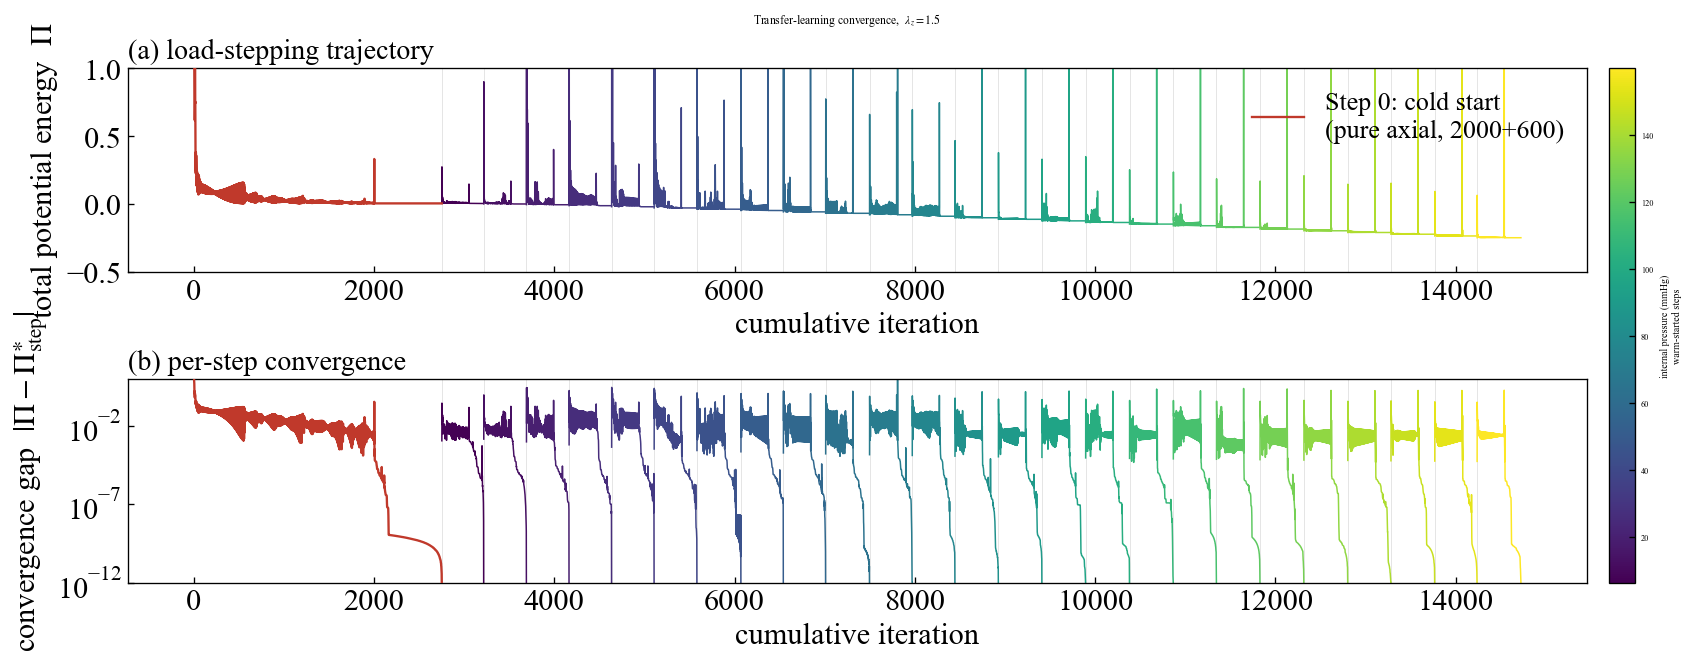

saved: ./pth/case3_loss_lz1.5.pdf / .png


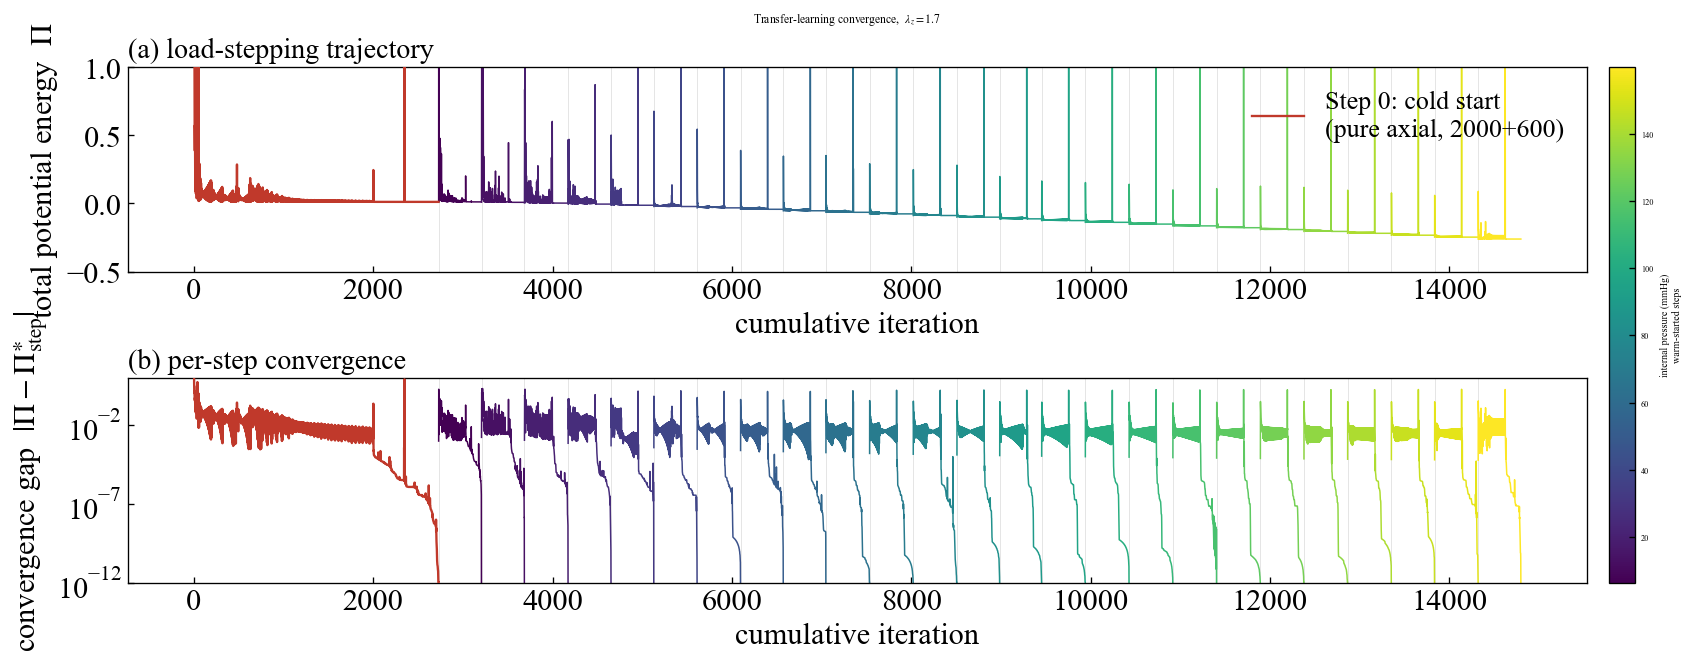

saved: ./pth/case3_loss_lz1.7.pdf / .png


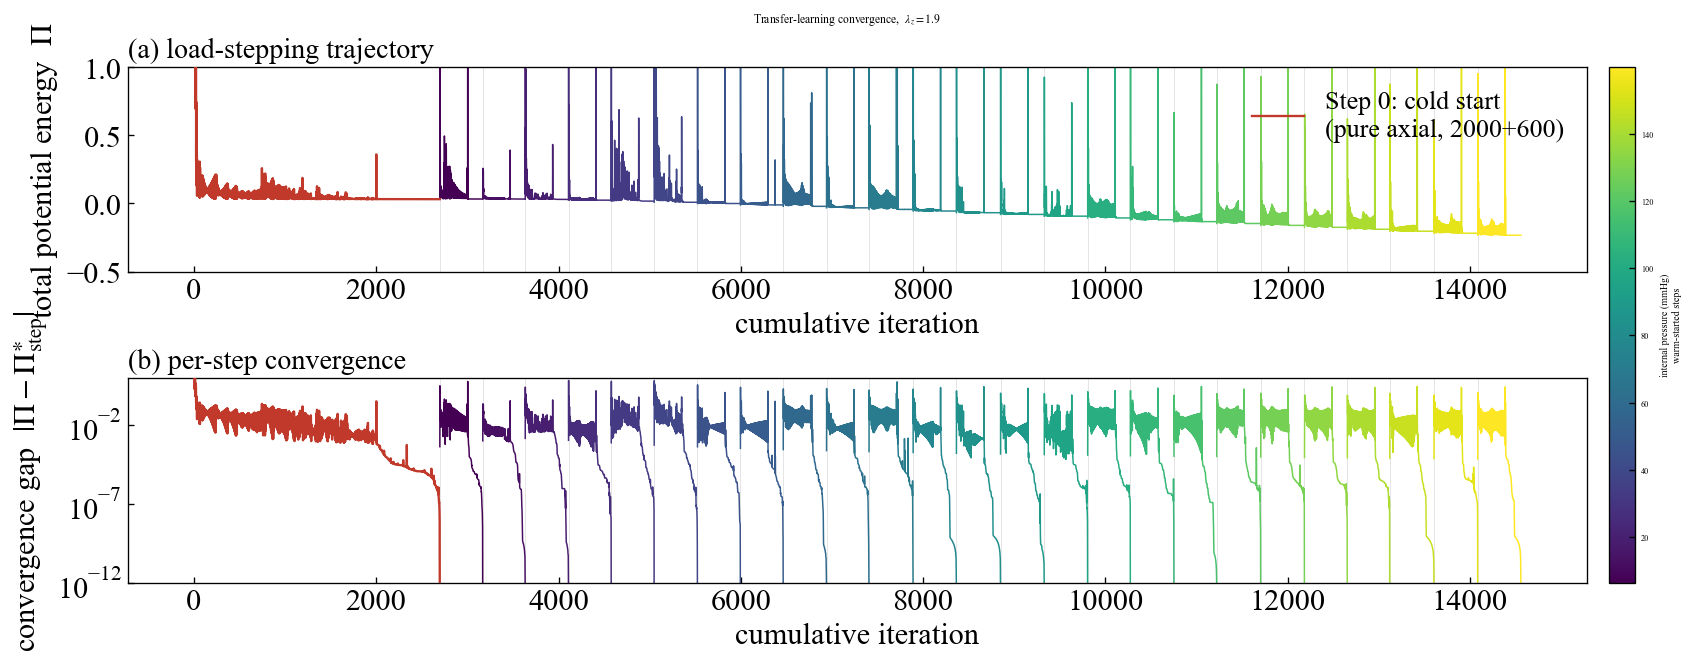

saved: ./pth/case3_loss_lz1.9.pdf / .png


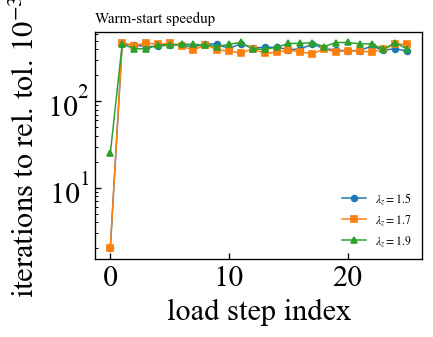

saved: ./pth/case3_iters_to_tol.pdf / .png


In [82]:
# =================== Case 3: Transfer-Learning Loss Curves (journal figure) ===================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import os, csv

assert 'all_loss_history_c3' in globals(), "loss history"
os.makedirs('./pth', exist_ok=True)

csv_path = './pth/case3_loss_history.csv'
with open(csv_path, 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['lambda_z', 'step', 'p_MPa', 'optimizer', 'iter',
                'loss', 'strain_energy', 'pressure_work'])
    for lz, hps in all_loss_history_c3.items():
        ps = step_pressures_c3[lz]
        for si, hist in enumerate(hps):
            for rec in hist:
                w.writerow([lz, si, ps[si], rec[0], rec[1], rec[2], rec[3], rec[4]])
print('saved:', csv_path)

# ---------- helpers ----------
MMHG  = 1000.0 / 0.133322
FLOOR = 1e-12
TOL   = 1e-3

def _step_loss(hist):
    return np.array([r[2] for r in hist], dtype=float)   # rec=(opt,iter,Pi,strain,pwork)

def _build_global(hist_per_step):
    segs_loss, segs_gap, bounds = [], [], [0]
    for hist in hist_per_step:
        L = _step_loss(hist)
        gap = np.maximum(np.abs(L - L.min()), FLOOR)   # |Π - Π*_step|
        segs_loss.append(L); segs_gap.append(gap)
        bounds.append(bounds[-1] + len(L))
    return np.concatenate(segs_loss), np.concatenate(segs_gap), bounds

def _iters_to_tol(hist, tol=TOL):
    L = _step_loss(hist); gap = np.abs(L - L.min())
    g0 = gap[0] if gap[0] > 0 else (gap.max() if gap.max() > 0 else 1.0)
    below = np.where(gap / g0 < tol)[0]
    return int(below[0] + 1) if below.size else len(L)
FS = 6   # 全局基准字号

JOURNAL_RC = {
    'font.family': 'serif',
    'font.size':       FS,
    'axes.titlesize':  FS,
    'axes.labelsize':  FS,
    'xtick.labelsize': FS - 1,
    'ytick.labelsize': FS - 1,
    'legend.fontsize': FS - 1,
    'axes.linewidth': 0.8,
    'xtick.direction': 'in', 'ytick.direction': 'in',
    'xtick.major.size': 3.5, 'ytick.major.size': 3.5,
    'legend.frameon': False, 'savefig.dpi': 600, 'figure.dpi': 120,
    'savefig.bbox': 'tight',
}

JOURNAL_RC = {
    'font.family': 'serif', 'font.size': 9, 'axes.linewidth': 0.8,
    'xtick.direction': 'in', 'ytick.direction': 'in',
    'xtick.major.size': 3.5, 'ytick.major.size': 3.5,
    'legend.frameon': False, 'savefig.dpi': 600, 'figure.dpi': 120,
    'savefig.bbox': 'tight',
}
def plot_transfer_loss(LZ_SHOW, save_prefix='./pth/case3_loss_lz',
                       ylim_raw=(-0.5,1), ylim_gap=(0.000000000001,10), figsize=(14, 5.4),
                       yscale_raw='linear', linthresh=1e-2):
    """
    yscale_raw : (a) 图纵轴类型，'linear' 或 'symlog'
    linthresh  : symlog 模式下 0 附近线性区的半宽（越小，近 0 振荡放得越大）
    ylim_raw   : (ymin, ymax) (a) 图纵轴范围（symlog 下可含负值/0）；None 自动
    ylim_gap   : (ymin, ymax) (b) 图纵轴范围（对数轴，须为正）；None 自动
    figsize    : (宽, 高) 英寸
    """
    hist_per_step = all_loss_history_c3[LZ_SHOW]
    press         = step_pressures_c3[LZ_SHOW]
    gloss, ggap, bounds = _build_global(hist_per_step)
    x = np.arange(len(gloss))

    warm_p_mmhg = np.array(press[1:]) * MMHG
    cmap = plt.cm.viridis
    norm = Normalize(vmin=warm_p_mmhg.min(), vmax=warm_p_mmhg.max())
    cold_c = '#c0392b'

    with plt.rc_context(JOURNAL_RC):
        fig, axes = plt.subplots(2, 1, figsize=figsize, constrained_layout=True)
        for ax, mode in zip(axes, ['raw', 'gap']):
            for si in range(len(hist_per_step)):
                lo, hi = bounds[si], bounds[si + 1]
                xs = x[lo:hi]
                ys = gloss[lo:hi] if mode == 'raw' else ggap[lo:hi]
                if si == 0:
                    ax.plot(xs, ys, color=cold_c, lw=1.4, zorder=3,
                            label='Step 0: cold start\n(pure axial, 2000+600)')
                else:
                    ax.plot(xs, ys, color=cmap(norm(press[si] * MMHG)), lw=0.9, zorder=2)
                    ax.axvline(bounds[si], color='0.88', lw=0.5, zorder=0)
            ax.set_xlabel('cumulative iteration')
            if mode == 'raw':
                ax.set_ylabel(r'total potential energy  $\Pi$')
                ax.set_title('(a) load-stepping trajectory', loc='left')
                if yscale_raw == 'symlog':                       # ← 对数感（可含负值）
                    ax.set_yscale('symlog', linthresh=linthresh)
                if ylim_raw is not None:
                    ax.set_ylim(ylim_raw)
            else:
                ax.set_yscale('log')
                ax.set_ylabel(r'convergence gap  $|\Pi-\Pi^{\ast}_{\mathrm{step}}|$')
                ax.set_title('(b) per-step convergence', loc='left')
                if ylim_gap is not None:
                    ax.set_ylim(ylim_gap)

        sm = ScalarMappable(norm=norm, cmap=cmap); sm.set_array([])
        cb = fig.colorbar(sm, ax=axes, pad=0.015, fraction=0.045)
        cb.set_label('internal pressure (mmHg)\nwarm-started steps', fontsize=FS)
        cb.ax.tick_params(labelsize=FS - 1)
        axes[0].legend(loc='upper right')
        fig.suptitle(rf'Transfer-learning convergence,  $\lambda_z={LZ_SHOW}$',
                     fontsize=FS + 1)

        out = f'{save_prefix}{LZ_SHOW:.1f}'
        fig.savefig(out + '.pdf'); fig.savefig(out + '.png', dpi=600)
        plt.show()
        print('saved:', out + '.pdf / .png')

# def plot_transfer_loss(LZ_SHOW, save_prefix='./pth/case3_loss_lz',
#                        ylim_raw=(-0.5,10), ylim_gap=None):
#     """
#     ylim_raw : (ymin, ymax) 控制 (a) 面板 Π 纵轴范围；None 为自动
#     ylim_gap : (ymin, ymax) 控制 (b) 面板 gap 纵轴范围（对数轴）；None 为自动
#     """
#     hist_per_step = all_loss_history_c3[LZ_SHOW]
#     press         = step_pressures_c3[LZ_SHOW]
#     gloss, ggap, bounds = _build_global(hist_per_step)
#     x = np.arange(len(gloss))

#     warm_p_mmhg = np.array(press[1:]) * MMHG
#     cmap = plt.cm.viridis
#     norm = Normalize(vmin=warm_p_mmhg.min(), vmax=warm_p_mmhg.max())
#     cold_c = '#c0392b'

#     with plt.rc_context(JOURNAL_RC):
#         # 两行一列
#         fig, axes = plt.subplots(2, 1, figsize=(14.0, 5.4), constrained_layout=True)
#         for ax, mode in zip(axes, ['raw', 'gap']):
#             for si in range(len(hist_per_step)):
#                 lo, hi = bounds[si], bounds[si + 1]
#                 xs = x[lo:hi]
#                 ys = gloss[lo:hi] if mode == 'raw' else ggap[lo:hi]
#                 if si == 0:
#                     ax.plot(xs, ys, color=cold_c, lw=1.4, zorder=3,
#                             label='Step 0: cold start\n(pure axial, 2000+600)')
#                 else:
#                     ax.plot(xs, ys, color=cmap(norm(press[si] * MMHG)), lw=0.9, zorder=2)
#                     ax.axvline(bounds[si], color='0.88', lw=0.5, zorder=0)
#             ax.set_xlabel('cumulative iteration')
#             if mode == 'raw':
#                 ax.set_ylabel(r'total potential energy  $\Pi$')
#                 ax.set_title('(a) load-stepping trajectory', fontsize=9, loc='left')
#                 if ylim_raw is not None:
#                     ax.set_ylim(ylim_raw)
#             else:
#                 ax.set_yscale('log')
#                 ax.set_ylabel(r'convergence gap  $|\Pi-\Pi^{\ast}_{\mathrm{step}}|$')
#                 ax.set_title('(b) per-step convergence', fontsize=9, loc='left')
#                 if ylim_gap is not None:
#                     ax.set_ylim(ylim_gap)

#         sm = ScalarMappable(norm=norm, cmap=cmap); sm.set_array([])
#         cb = fig.colorbar(sm, ax=axes, pad=0.015, fraction=0.045)
#         cb.set_label('internal pressure (mmHg)\nwarm-started steps')
#         axes[0].legend(loc='upper right', fontsize=7)
#         fig.suptitle(rf'Transfer-learning convergence,  $\lambda_z={LZ_SHOW}$', fontsize=10)

#         out = f'{save_prefix}{LZ_SHOW:.1f}'
#         fig.savefig(out + '.pdf'); fig.savefig(out + '.png', dpi=600)
#         plt.show()
#         print('saved:', out + '.pdf / .png')

# # ---------- 图 2：warm-start 加速（各步收敛所需迭代数）----------
def plot_speedup(save='./pth/case3_iters_to_tol'):
    markers = {1.5: 'o', 1.7: 's', 1.9: '^'}
    with plt.rc_context(JOURNAL_RC):
        fig, ax = plt.subplots(figsize=(3.5, 2.7), constrained_layout=True)
        for lz in all_loss_history_c3:
            its = [_iters_to_tol(h) for h in all_loss_history_c3[lz]]
            ax.plot(range(len(its)), its, marker=markers.get(lz, 'o'),
                    ms=3.5, lw=0.9, label=rf'$\lambda_z={lz}$')
        ax.set_yscale('log')
        ax.set_xlabel('load step index')
        ax.set_ylabel(r'iterations to rel. tol. $10^{-3}$')
        ax.set_title('Warm-start speedup', fontsize=9, loc='left')
        ax.legend(fontsize=7)
        fig.savefig(save + '.pdf'); fig.savefig(save + '.png', dpi=600)
        plt.show()
        print('saved:', save + '.pdf / .png')


for lz in lambda_z_list:
    plot_transfer_loss(lz)
plot_speedup()

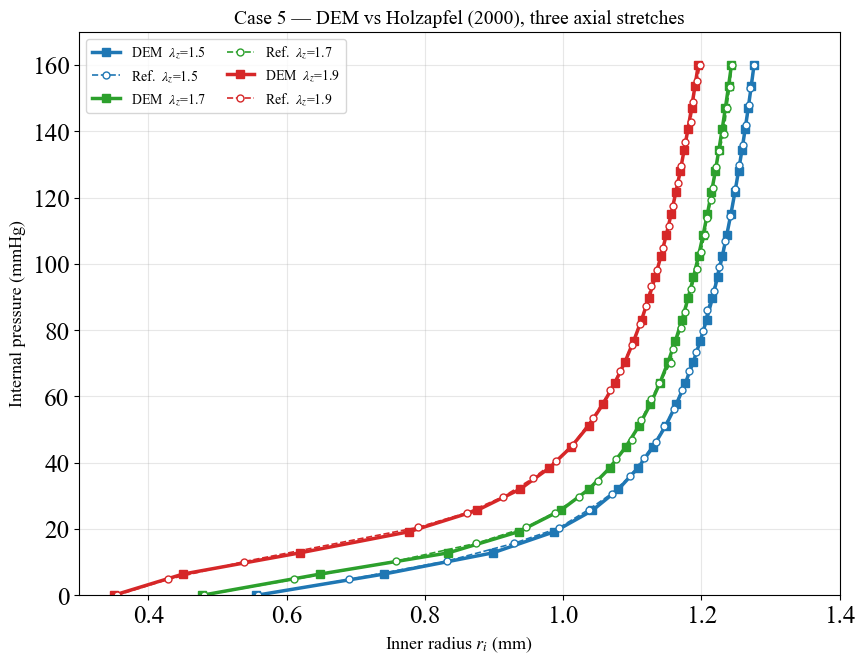

In [48]:
# Referrence data
ref_data = {
    1.5: {'ri': [0.55875, 0.69061, 0.83234, 0.92924, 0.99384, 1.03692, 1.07013, 
               1.09706, 1.11682, 1.13389, 1.14647, 1.15996, 1.17165, 1.18244, 
               1.19234, 1.20224, 1.20855, 1.21756, 1.22477, 1.23468, 1.24190, 
               1.24912, 1.25454, 1.25995, 1.26447, 1.26899, 1.27081, 1.27623],
        'pi': [0.00000, 4.80370, 10.34642, 15.70439, 20.32333, 25.86605, 
               30.66975, 36.02771, 41.57044, 46.37413, 50.99307, 56.16628, 
               61.89376, 67.62125, 73.34873, 79.63048, 86.09700, 91.82448, 
               99.03002, 106.97460, 114.54965, 122.67898, 129.69977, 135.79677, 
               141.89376, 147.99076, 152.97921, 160.00000]},
    1.7: {
        'ri': [0.47982, 0.61079, 0.75880, 0.87453, 0.94630, 0.98758, 1.02349, 
               1.05042, 1.07646, 1.09892, 1.11330, 1.12679, 1.13937, 1.15555, 
               1.15826, 1.17086, 1.17626, 1.18527, 1.19427, 1.19879, 1.20509, 
               1.20781, 1.21412, 1.21683, 1.22135, 1.22586, 1.23217, 1.23670, 1.24122, 1.24395],
        'pi': [0.00000, 4.80370, 10.34642, 15.70439, 20.50808, 24.94226, 
               29.74596, 34.36490, 41.20092, 46.74365, 52.84065, 59.12240, 
               63.92610, 70.20785, 74.45727, 80.55427, 85.54273, 92.37875, 
               98.47575, 103.46420, 108.63741, 113.81062, 119.35335, 123.04850, 
               129.33025, 133.94919, 139.12240, 147.06697, 153.53349, 160.00000 ]},

    1.9:{'ri': [0.35426, 0.42873, 0.53817, 0.79025, 0.86113, 0.91317, 0.95625, 
                0.98947, 1.01371, 1.04335, 1.06851, 1.08199, 1.09908, 1.11077, 
                1.11977, 1.12698, 1.13598, 1.14409, 1.15309, 1.15851, 1.16662, 
                1.17113, 1.17655, 1.18466, 1.18738, 1.19370, 1.198200],
        'pi': [0.00000, 4.80370, 10.16166, 20.50808, 24.94226, 29.74596, 
               35.28868, 40.64665, 45.45035, 53.57968, 61.89376, 67.62125, 
               75.38106, 81.84758, 87.39030, 93.30254, 98.10624, 104.94226, 
               111.40878, 117.50577, 124.34180, 129.51501, 136.72055, 142.81755, 148.91455, 155.19630, 160.0000]},
}


color_map = {
    1.5: {'dem': '#1f77b4', 'ref': '#1f77b4'},  
    1.7: {'dem': '#2ca02c', 'ref': '#2ca02c'},   
    1.9: {'dem': '#d62728', 'ref': '#d62728'},   
}

fig, ax = plt.subplots(1, 1, figsize=(9, 7))

for lambda_z in lambda_z_list:
    c = color_map[lambda_z]

    ax.plot(all_ri[lambda_z], all_pi[lambda_z],
            color=c['dem'], marker='s', ms=6, lw=2.5, ls='-',
            label=f'DEM  $\\lambda_z$={lambda_z}')
    

    if lambda_z in ref_data:
        ax.plot(ref_data[lambda_z]['ri'], ref_data[lambda_z]['pi'],
                color=c['ref'], marker='o', ms=5, lw=1.2, ls='--',
                mfc='white', mec=c['ref'],
                label=f'Ref.  $\\lambda_z$={lambda_z}')

ax.set_xlabel('Inner radius $r_i$ (mm)', fontsize=13)
ax.set_ylabel('Internal pressure (mmHg)', fontsize=13)
ax.set_title('Case 5 — DEM vs Holzapfel (2000), three axial stretches',
             fontsize=14)
# ax.legend(fontsize=10, loc='upper left', ncol=2)
from matplotlib.lines import Line2D


c15 = color_map[1.5]
c17 = color_map[1.7]
c19 = color_map[1.9]


h_dem_15 = Line2D([0],[0], color=c15['dem'], marker='s', ms=6, lw=2.5, ls='-',
                  label='DEM  $\\lambda_z$=1.5')
h_dem_17 = Line2D([0],[0], color=c17['dem'], marker='s', ms=6, lw=2.5, ls='-',
                  label='DEM  $\\lambda_z$=1.7')
h_dem_19 = Line2D([0],[0], color=c19['dem'], marker='s', ms=6, lw=2.5, ls='-',
                  label='DEM  $\\lambda_z$=1.9')

h_ref_15 = Line2D([0],[0], color=c15['ref'], marker='o', ms=5, lw=1.2, ls='--',
                  mfc='white', mec=c15['ref'], label='Ref.  $\\lambda_z$=1.5')
h_ref_17 = Line2D([0],[0], color=c17['ref'], marker='o', ms=5, lw=1.2, ls='--',
                  mfc='white', mec=c17['ref'], label='Ref.  $\\lambda_z$=1.7')
h_ref_19 = Line2D([0],[0], color=c19['ref'], marker='o', ms=5, lw=1.2, ls='--',
                  mfc='white', mec=c19['ref'], label='Ref.  $\\lambda_z$=1.9')

legend_elements = [
    h_dem_15, h_ref_15,
    h_dem_17, h_ref_17,
    h_dem_19, h_ref_19,
]

ax.legend(handles=legend_elements, fontsize=10, loc='upper left',
          ncol=2, columnspacing=1.5)
ax.grid(True, alpha=0.3)
ax.set_xlim(0.3, 1.4)
ax.set_ylim(0, 170)

plt.tight_layout()
plt.savefig('./pth/case5_pi_ri_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
def plot_transfer_learning_academic(adam_loss, lbfgs_loss, transfer_step):
    fig, ax = plt.subplots(figsize=(8, 5))
    

    all_loss = adam_loss + lbfgs_loss
    steps = range(len(all_loss))
 
    ax.plot(steps, all_loss, color='#2c3e50', lw=1.5, label='Total Loss (Energy)')
    

    ax.axvspan(0, transfer_step, color='#f0f2f5', alpha=0.5, label='Pre-training Phase')
    ax.axvspan(transfer_step, len(all_loss), color='#e3f2fd', alpha=0.5, label='Fine-tuning Phase')
    

    ax.axvline(transfer_step, color='#e74c3c', linestyle='--', lw=1.2)
    ax.text(transfer_step, max(all_loss)*0.8, ' Transfer Trigger ', 
            rotation=90, verticalalignment='center', fontsize=9, color='#e74c3c')
    

    ax.set_yscale('log') 
    ax.set_xlabel('Iteration Steps', fontsize=12, fontweight='bold')
    ax.set_ylabel('Objective Function Value (log)', fontsize=12, fontweight='bold')
    ax.set_title('Convergence History: Knowledge Transfer', fontsize=14, pad=15)
    

    ax.grid(True, which='both', linestyle=':', alpha=0.6)
    ax.legend(loc='upper right', fontsize=10, frameon=True)
    
    plt.tight_layout()

    plt.savefig('./pth/transfer_learning_loss.pdf', dpi=300)
    plt.show()


In [28]:
# ===================Case 3: 3D Onion-Skin DEM vs FEM vs Error (λz=1.7, p=160 mmHg)===================
# Three rows: FEM | DEM | Error. Switch u_r / σ_θθ via drop-down menu; stress 
import numpy as np
import plotly.graph_objects as go
from scipy.interpolate import griddata

MPA_TO_KPA = 1.0
target_lz  = 1.7
dz_plot    = (target_lz - 1.0) * L


net_plot = DEM_Network(Ri, Ro, L)
net_plot.load_state_dict(
    torch.load(f'./pth/case5_dem_lz{target_lz:.1f}.pt', map_location=device))
net_plot.eval()

def bc_fn_plot(rz, y_hat):
    return apply_hard_BC_pressure_axial(rz, y_hat, L, dz_plot)


nr_v, nz_v = R_grid_c5.shape
with torch.no_grad():
    u_pred = bc_fn_plot(RZdata_c5, net_plot(RZdata_c5)).cpu().numpy()

r_arr = R_grid_c5.cpu().numpy()
z_arr = Z_grid_c5.cpu().numpy()
ur_dem = u_pred[:, 0].reshape(nr_v, nz_v)   # (nr,nz) [mm]
uz_dem = u_pred[:, 1].reshape(nr_v, nz_v)   

rz_g  = RZdata_c5.clone().requires_grad_(True)
u_g   = bc_fn_plot(rz_g, net_plot(rz_g))
F_pred = compute_deformation_gradient(u_g, rz_g)
_, J_pred = energy_fn_c5(F_pred)
F_all = F_pred.detach().cpu().numpy().reshape(nr_v, nz_v, 3, 3)
J_all = J_pred.detach().cpu().numpy().reshape(nr_v, nz_v)

a1m_np, a2m_np = a1_media_c5.cpu().numpy(), a2_media_c5.cpu().numpy()
a1a_np, a2a_np = a1_adv_c5.cpu().numpy(),   a2_adv_c5.cpu().numpy()

r_col = r_arr[:, 0]
stt_dem = np.zeros((nr_v, nz_v))   # σθθ [MPa]
for j in range(nz_v):
    for i in range(nr_v):
        if r_col[i] < Rm:
            ps, a1n, a2n = params_media, a1m_np, a2m_np
        else:
            ps, a1n, a2n = params_adventitia, a1a_np, a2a_np
        sig = compute_cauchy_stress_np(F_all[i, j], J_all[i, j], ps, a1n, a2n)
        stt_dem[i, j] = sig[1, 1] * MPA_TO_KPA

print(f"DEM ur  range: [{ur_dem.min():.4f}, {ur_dem.max():.4f}] mm")
print(f"DEM σθθ range: [{stt_dem.min():.2f}, {stt_dem.max():.2f}] MPa")
print(f"DEM J   range: [{J_all.min():.4f}, {J_all.max():.4f}]")


rpt_path = r"E:\QL\DEM_HGO\codes\new\bilayer-ax175-pr.rpt"  

fem_data = []
with open(rpt_path, 'r') as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) == 10:
            try:
                fem_data.append([float(x) for x in parts])
            except ValueError:
                pass
fem_data = np.array(fem_data)
if fem_data.size == 0:
    raise RuntimeError(f"❌Failed to parse 10 columns of data from {rpt_path}")
print(f"FEM numbers of Nodes: {fem_data.shape[0]}")

r_fem_cur = fem_data[:, 1]                 
z_fem_cur = fem_data[:, 3]                 
ur_fem_n  = fem_data[:, 4]                 
stt_fem_n = fem_data[:, 8] * MPA_TO_KPA    


r_fem_ref = r_fem_cur - ur_fem_n

z_fem_min, z_fem_max = z_fem_cur.min(), z_fem_cur.max()
z_fem_ref = (z_fem_cur - z_fem_min) / (z_fem_max - z_fem_min) * L

pts_fem = np.column_stack([r_fem_ref, z_fem_ref])
pts_dem = np.column_stack([r_arr.flatten(), z_arr.flatten()])

ur_fem  = griddata(pts_fem, ur_fem_n,  pts_dem, method='linear').reshape(nr_v, nz_v)
stt_fem = griddata(pts_fem, stt_fem_n, pts_dem, method='linear').reshape(nr_v, nz_v)

for arr_itp, vals in [(ur_fem, ur_fem_n), (stt_fem, stt_fem_n)]:
    nan_mask = np.isnan(arr_itp)
    if nan_mask.any():
        arr_itp[nan_mask] = griddata(pts_fem, vals, pts_dem[nan_mask.flatten()],
                                     method='nearest')

print(f"FEM ur  range: [{np.nanmin(ur_fem):.4f}, {np.nanmax(ur_fem):.4f}] mm")
print(f"FEM σθθ range: [{np.nanmin(stt_fem):.2f}, {np.nanmax(stt_fem):.2f}] MPa")


p_mmhg = p_max_c5 * 1.0 / 0.133322
title_base = f"λz={target_lz} | p={p_mmhg:.0f} mmHg"

fields = {
    'u_r (mm)':   {'fem': ur_fem,  'dem': ur_dem,  'cmap_v': 'Jet', 'cmap_e': 'RdBu', 'err_label': 'Δu_r (mm)'},
    'σ_θθ (MPa)': {'fem': stt_fem, 'dem': stt_dem, 'cmap_v': 'Jet', 'cmap_e': 'RdBu', 'err_label': 'Δσ_θθ (kPa)'},
}
field_names = list(fields.keys())


r_1d = r_arr[:, 0]
z_1d = z_arr[0, :]
N_THETA = 91

def make_layer_mesh(ir):
    th = np.linspace(0, 2*np.pi, N_THETA)
    Theta, Z = np.meshgrid(th, z_1d, indexing='ij')
    Ur = np.tile(ur_dem[ir, :][None, :], (N_THETA, 1))
    Uz = np.tile(uz_dem[ir, :][None, :], (N_THETA, 1))
    r_def = r_1d[ir] + Ur
    return r_def*np.cos(Theta), Z + Uz, r_def*np.sin(Theta)

def make_cap_mesh(iz):
    th = np.linspace(0, 2*np.pi, N_THETA)
    Theta, R = np.meshgrid(th, r_1d, indexing='ij')
    Ur = np.tile(ur_dem[:, iz][None, :], (N_THETA, 1))
    Uz = np.tile(uz_dem[:, iz][None, :], (N_THETA, 1))
    r_def = R + Ur
    return r_def*np.cos(Theta), z_1d[iz] + Uz, r_def*np.sin(Theta)

def field_to_layer(ir, fg): return np.tile(fg[ir, :][None, :], (N_THETA, 1))
def field_to_cap(iz, fg):   return np.tile(fg[:, iz][None, :], (N_THETA, 1))


def build_surface_traces(field_grid, cmap, scene_name, showscale,
                         col_idx, vmin=None, vmax=None, cb_title=''):
    traces = []
    if vmin is None: vmin = np.nanmin(field_grid)
    if vmax is None: vmax = np.nanmax(field_grid)
    fp = np.where(np.isfinite(field_grid), field_grid, vmin)
    for ir in range(nr_v):
        X, Y, Zp = make_layer_mesh(ir)
        show_cb = showscale and (ir == nr_v - 1)
        traces.append(go.Surface(
            x=X, y=Y, z=Zp, surfacecolor=field_to_layer(ir, fp),
            colorscale=cmap, cmin=vmin, cmax=vmax, showscale=show_cb,
            colorbar=dict(len=0.28, thickness=15, x=0.88,
                          y=0.85 - col_idx*0.35, yanchor='middle',
                          title=dict(text=cb_title, side='right')) if show_cb else None,
            scene=scene_name, opacity=1.0, hoverinfo='skip',
            lighting=dict(ambient=0.7, diffuse=0.5, specular=0.1, roughness=0.8)))
    for iz in [0, -1]:
        X, Y, Zp = make_cap_mesh(iz)
        traces.append(go.Surface(
            x=X, y=Y, z=Zp, surfacecolor=field_to_cap(iz, fp),
            colorscale=cmap, cmin=vmin, cmax=vmax, showscale=False,
            scene=scene_name, opacity=1.0, hoverinfo='skip',
            lighting=dict(ambient=0.7, diffuse=0.5, specular=0.1, roughness=0.8)))
    return traces

def build_outline_traces(scene_name):
    traces = []
    th_c = np.linspace(0, 2*np.pi, 361)
    ls = dict(color='black', width=2)
    for ir_idx, iz_idx in [(-1, 0), (0, 0), (-1, -1), (0, -1)]:
        r_def = r_1d[ir_idx] + ur_dem[ir_idx, iz_idx]
        y_val = z_1d[iz_idx] + uz_dem[ir_idx, iz_idx]
        traces.append(go.Scatter3d(
            x=r_def*np.cos(th_c), y=np.full_like(th_c, y_val), z=r_def*np.sin(th_c),
            mode='lines', line=ls, showlegend=False, hoverinfo='skip', scene=scene_name))
    for th_val in [0, np.pi/2, np.pi, 3*np.pi/2]:
        r_line = r_1d[-1] + ur_dem[-1, :]
        traces.append(go.Scatter3d(
            x=r_line*np.cos(th_val), y=z_1d + uz_dem[-1, :], z=r_line*np.sin(th_val),
            mode='lines', line=ls, showlegend=False, hoverinfo='skip', scene=scene_name))
    return traces


print("Building traces...")
all_traces = []
traces_per_field = []
for f_name in field_names:
    fd = fields[f_name]
    err_field = fd['dem'] - fd['fem']
    vmin_f, vmax_f = np.nanmin(fd['fem']), np.nanmax(fd['fem'])
    vmin_d, vmax_d = np.nanmin(fd['dem']), np.nanmax(fd['dem'])
    ef = err_field[np.isfinite(err_field)]
    err_max = max(abs(np.percentile(ef, 1)), abs(np.percentile(ef, 99))) if len(ef) else 1.0
    print(f"  {f_name}: err 1-99% = [{-err_max:.4e}, {err_max:.4e}]")

    n0 = len(all_traces)
    # FEM (scene)
    all_traces += build_surface_traces(fd['fem'], fd['cmap_v'], 'scene', True, 0, vmin_f, vmax_f, f_name)
    all_traces += build_outline_traces('scene')
    # DEM (scene2)
    all_traces += build_surface_traces(fd['dem'], fd['cmap_v'], 'scene2', True, 1, vmin_d, vmax_d, f_name)
    all_traces += build_outline_traces('scene2')
    # Error (scene3)
    all_traces += build_surface_traces(err_field, fd['cmap_e'], 'scene3', True, 2, -err_max, err_max, fd['err_label'])
    all_traces += build_outline_traces('scene3')
    traces_per_field.append(len(all_traces) - n0)

total_traces = len(all_traces)

buttons = []
for fi, f_name in enumerate(field_names):
    vis = [False]*total_traces
    start = sum(traces_per_field[:fi])
    for i in range(start, start + traces_per_field[fi]):
        vis[i] = True
    buttons.append(dict(label=f_name, method='update',
        args=[{'visible': vis}, {'title': f'Case 5: {f_name} | {title_base}'}]))
for i, tr in enumerate(all_traces):
    tr.visible = (i < traces_per_field[0])


scene_common = dict(
    xaxis_title='x (mm)', yaxis_title='z (mm)', zaxis_title='y (mm)',
    aspectmode='manual',
    aspectratio=dict(x=1, y=L*target_lz/(2*Ro), z=1),
    camera=dict(eye=dict(x=1.5, y=-1.8, z=1.2)), bgcolor='white')

def make_scene(yb, yt):
    s = dict(**scene_common); s['domain'] = dict(x=[0.0, 0.85], y=[yb, yt]); return s

layout = go.Layout(
    title=dict(text=f'Case 5: {field_names[0]} | {title_base}', x=0.42, font=dict(size=16)),
    paper_bgcolor='white',
    scene =make_scene(0.70, 1.00),
    scene2=make_scene(0.35, 0.65),
    scene3=make_scene(0.00, 0.30),
    updatemenus=[dict(type='dropdown', x=0.42, y=1.04, xanchor='center',
        buttons=buttons, bgcolor='white', bordercolor='gray',
        font=dict(size=13), showactive=True, active=0)],
    annotations=[
        dict(text='FEM',           x=0.42, y=1.01, xref='paper', yref='paper', showarrow=False, font=dict(size=14), xanchor='center'),
        dict(text='DEM',           x=0.42, y=0.66, xref='paper', yref='paper', showarrow=False, font=dict(size=14), xanchor='center'),
        dict(text='Error (DEM − FEM)', x=0.42, y=0.31, xref='paper', yref='paper', showarrow=False, font=dict(size=14), xanchor='center'),
    ],
    width=1000, height=1800, margin=dict(l=20, r=160, t=80, b=20))

fig_plotly = go.Figure(data=all_traces, layout=layout)


HTML_OUT = './pth/case5_3d_dem_vs_fem.html'

fig_plotly.write_html(HTML_OUT)
print(f"Saved HTML: {HTML_OUT}")

err_ur  = ur_dem - ur_fem
err_stt = stt_dem - stt_fem
ur_rms  = np.sqrt(np.nanmean(ur_fem**2))
stt_rms = np.sqrt(np.nanmean(stt_fem**2))
err_ur_L2  = np.sqrt(np.nansum(err_ur**2))  / np.sqrt(np.nansum(ur_fem**2))
err_stt_L2 = np.sqrt(np.nansum(err_stt**2)) / np.sqrt(np.nansum(stt_fem**2))



DEM ur  range: [0.3010, 0.5344] mm
DEM σθθ range: [0.00, 1.11] MPa
DEM J   range: [1.0008, 1.0234]
FEM numbers of Nodes: 82656
FEM ur  range: [0.2948, 0.5270] mm
FEM σθθ range: [0.01, 1.10] MPa
Building traces...
  u_r (mm): err 1-99% = [-7.4950e-03, 7.4950e-03]
  σ_θθ (MPa): err 1-99% = [-5.7521e-02, 5.7521e-02]
Saved HTML: ./pth/case5_3d_dem_vs_fem.html


In [29]:

import numpy as np
import plotly.graph_objects as go
from scipy.interpolate import griddata

MPA_TO_KPA = 1.0          
target_lz  = 1.7
dz_plot    = (target_lz - 1.0) * L


net_plot = DEM_Network(Ri, Ro, L)
net_plot.load_state_dict(
    torch.load(f'./pth/case5_dem_lz{target_lz:.1f}.pt', map_location=device))
net_plot.eval()

def bc_fn_plot(rz, y_hat):
    return apply_hard_BC_pressure_axial(rz, y_hat, L, dz_plot)


nr_v, nz_v = R_grid_c5.shape
with torch.no_grad():
    u_pred = bc_fn_plot(RZdata_c5, net_plot(RZdata_c5)).cpu().numpy()

r_arr  = R_grid_c5.cpu().numpy()
z_arr  = Z_grid_c5.cpu().numpy()
ur_dem = u_pred[:, 0].reshape(nr_v, nz_v)
uz_dem = u_pred[:, 1].reshape(nr_v, nz_v)

rz_g  = RZdata_c5.clone().requires_grad_(True)
u_g   = bc_fn_plot(rz_g, net_plot(rz_g))
F_pred = compute_deformation_gradient(u_g, rz_g)
_, J_pred = energy_fn_c5(F_pred)
F_all = F_pred.detach().cpu().numpy().reshape(nr_v, nz_v, 3, 3)
J_all = J_pred.detach().cpu().numpy().reshape(nr_v, nz_v)

a1m_np, a2m_np = a1_media_c5.cpu().numpy(), a2_media_c5.cpu().numpy()
a1a_np, a2a_np = a1_adv_c5.cpu().numpy(),   a2_adv_c5.cpu().numpy()

r_col   = r_arr[:, 0]
stt_dem = np.zeros((nr_v, nz_v))   # σθθ [MPa]
for j in range(nz_v):
    for i in range(nr_v):
        if r_col[i] < Rm:
            ps, a1n, a2n = params_media,      a1m_np, a2m_np
        else:
            ps, a1n, a2n = params_adventitia, a1a_np, a2a_np
        sig = compute_cauchy_stress_np(F_all[i, j], J_all[i, j], ps, a1n, a2n)
        stt_dem[i, j] = sig[1, 1] * MPA_TO_KPA

print(f"DEM ur  range: [{ur_dem.min():.4f}, {ur_dem.max():.4f}] mm")
print(f"DEM σθθ range: [{stt_dem.min():.4f}, {stt_dem.max():.4f}] MPa")
print(f"DEM J   range: [{J_all.min():.4f}, {J_all.max():.4f}]")


rpt_path = r"E:\QL\DEM_HGO\codes\new\bilayer-ax175-pr.rpt"

fem_data = []
with open(rpt_path, 'r') as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) == 10:
            try:
                fem_data.append([float(x) for x in parts])
            except ValueError:
                pass
fem_data = np.array(fem_data)
if fem_data.size == 0:
    raise RuntimeError(f"❌Failed to parse 10 columns of data from {rpt_path} ")
print(f"FEM numbers of nodes {fem_data.shape[0]}")

r_fem_cur = fem_data[:, 1]
z_fem_cur = fem_data[:, 3]
ur_fem_n  = fem_data[:, 4]
stt_fem_n = fem_data[:, 8] * MPA_TO_KPA   # σθθ [MPa]

r_fem_ref = r_fem_cur - ur_fem_n
z_fem_min, z_fem_max = z_fem_cur.min(), z_fem_cur.max()
z_fem_ref = (z_fem_cur - z_fem_min) / (z_fem_max - z_fem_min) * L


pts_fem = np.column_stack([r_fem_ref, z_fem_ref])
pts_dem = np.column_stack([r_arr.flatten(), z_arr.flatten()])

ur_fem  = griddata(pts_fem, ur_fem_n,  pts_dem, method='linear').reshape(nr_v, nz_v)
stt_fem = griddata(pts_fem, stt_fem_n, pts_dem, method='linear').reshape(nr_v, nz_v)
for arr_itp, vals in [(ur_fem, ur_fem_n), (stt_fem, stt_fem_n)]:
    nan_mask = np.isnan(arr_itp)
    if nan_mask.any():
        arr_itp[nan_mask] = griddata(pts_fem, vals,
                                     pts_dem[nan_mask.flatten()], method='nearest')

print(f"FEM ur  range: [{np.nanmin(ur_fem):.4f}, {np.nanmax(ur_fem):.4f}] mm")
print(f"FEM σθθ range: [{np.nanmin(stt_fem):.4f}, {np.nanmax(stt_fem):.4f}] MPa")


ur_L2_norm  = np.sqrt(np.nansum(ur_fem**2))
stt_L2_norm = np.sqrt(np.nansum(stt_fem**2))


err_ur_abs  = ur_dem  - ur_fem
err_stt_abs = stt_dem - stt_fem
err_ur_L2dist  = np.abs(err_ur_abs)  / ur_L2_norm   
err_stt_L2dist = np.abs(err_stt_abs) / stt_L2_norm  


err_ur_L2  = np.sqrt(np.nansum(err_ur_abs**2))  / ur_L2_norm
err_stt_L2 = np.sqrt(np.nansum(err_stt_abs**2)) / stt_L2_norm

print(f"L²-error dist. ur  range: [{err_ur_L2dist.min():.2e}, {err_ur_L2dist.max():.2e}]")
print(f"L²-error dist. σθθ range: [{err_stt_L2dist.min():.2e}, {err_stt_L2dist.max():.2e}]")


p_mmhg     = p_max_c5 * 1.0 / 0.133322
title_base = f"λz={target_lz} | p={p_mmhg:.0f} mmHg"

fields = {
    'u_r (mm)': {
        'fem':        ur_fem,
        'dem':        ur_dem,
        'err':        err_ur_L2dist,
        'cmap_v':     'Jet',
        'cmap_e':     'YlGnBu',
        'err_label':  '|Δu_r,i| / ‖u_r^FEM‖₂',
    },
    'σ_θθ (MPa)': {
        'fem':        stt_fem,
        'dem':        stt_dem,
        'err':        err_stt_L2dist,
        'cmap_v':     'Jet',
        'cmap_e':     'YlGnBu',
        'err_label':  '|Δσ_θθ,i| / ‖σ_θθ^FEM‖₂',
    },
}
field_names = list(fields.keys())

r_1d    = r_arr[:, 0]
z_1d    = z_arr[0, :]
N_THETA = 91

def make_layer_mesh(ir):
    th = np.linspace(0, 2*np.pi, N_THETA)
    Theta, Z = np.meshgrid(th, z_1d, indexing='ij')
    Ur = np.tile(ur_dem[ir, :][None, :], (N_THETA, 1))
    Uz = np.tile(uz_dem[ir, :][None, :], (N_THETA, 1))
    r_def = r_1d[ir] + Ur
    return r_def*np.cos(Theta), Z + Uz, r_def*np.sin(Theta)

def make_cap_mesh(iz):
    th = np.linspace(0, 2*np.pi, N_THETA)
    Theta, R = np.meshgrid(th, r_1d, indexing='ij')
    Ur = np.tile(ur_dem[:, iz][None, :], (N_THETA, 1))
    Uz = np.tile(uz_dem[:, iz][None, :], (N_THETA, 1))
    r_def = R + Ur
    return r_def*np.cos(Theta), z_1d[iz] + Uz, r_def*np.sin(Theta)

def field_to_layer(ir, fg): return np.tile(fg[ir, :][None, :], (N_THETA, 1))
def field_to_cap(iz, fg):   return np.tile(fg[:, iz][None, :], (N_THETA, 1))


def build_surface_traces(field_grid, cmap, scene_name, showscale,
                         col_idx, vmin=None, vmax=None, cb_title=''):
    traces = []
    if vmin is None: vmin = np.nanmin(field_grid)
    if vmax is None: vmax = np.nanmax(field_grid)
    fp = np.where(np.isfinite(field_grid), field_grid, vmin)
    for ir in range(nr_v):
        X, Y, Zp = make_layer_mesh(ir)
        show_cb = showscale and (ir == nr_v - 1)
        traces.append(go.Surface(
            x=X, y=Y, z=Zp, surfacecolor=field_to_layer(ir, fp),
            colorscale=cmap, cmin=vmin, cmax=vmax, showscale=show_cb,
            colorbar=dict(len=0.28, thickness=15, x=0.88,
                          y=0.85 - col_idx*0.35, yanchor='middle',
                          title=dict(text=cb_title, side='right') ,
                          exponentformat='e',
                          ) if show_cb else None,
            scene=scene_name, opacity=1.0, hoverinfo='skip',
            lighting=dict(ambient=0.7, diffuse=0.5, specular=0.1, roughness=0.8)))
    for iz in [0, -1]:
        X, Y, Zp = make_cap_mesh(iz)
        traces.append(go.Surface(
            x=X, y=Y, z=Zp, surfacecolor=field_to_cap(iz, fp),
            colorscale=cmap, cmin=vmin, cmax=vmax, showscale=False,
            scene=scene_name, opacity=1.0, hoverinfo='skip',
            lighting=dict(ambient=0.7, diffuse=0.5, specular=0.1, roughness=0.8)))
    return traces

def build_outline_traces(scene_name):
    traces = []
    th_c = np.linspace(0, 2*np.pi, 361)
    ls   = dict(color='black', width=2)
    for ir_idx, iz_idx in [(-1, 0), (0, 0), (-1, -1), (0, -1)]:
        r_def = r_1d[ir_idx] + ur_dem[ir_idx, iz_idx]
        y_val = z_1d[iz_idx] + uz_dem[ir_idx, iz_idx]
        traces.append(go.Scatter3d(
            x=r_def*np.cos(th_c), y=np.full_like(th_c, y_val), z=r_def*np.sin(th_c),
            mode='lines', line=ls, showlegend=False, hoverinfo='skip', scene=scene_name))
    for th_val in [0, np.pi/2, np.pi, 3*np.pi/2]:
        r_line = r_1d[-1] + ur_dem[-1, :]
        traces.append(go.Scatter3d(
            x=r_line*np.cos(th_val), y=z_1d + uz_dem[-1, :], z=r_line*np.sin(th_val),
            mode='lines', line=ls, showlegend=False, hoverinfo='skip', scene=scene_name))
    return traces


print("Building traces...")
all_traces = []
traces_per_field = []

for f_name in field_names:
    fd = fields[f_name]
    err_field = fd['err']                          
    vmin_f = np.nanmin(fd['fem'])
    vmax_f = np.nanmax(fd['fem'])
    vmin_d = np.nanmin(fd['dem'])
    vmax_d = np.nanmax(fd['dem'])
    vmin_e = 0.0                                   
    vmax_e = np.nanmax(err_field)
    print(f"  {f_name}: L²-error dist. range = [0, {vmax_e:.4e}]")

    n0 = len(all_traces)
    # FEM (scene)
    all_traces += build_surface_traces(
        fd['fem'], fd['cmap_v'], 'scene',  True, 0, vmin_f, vmax_f, f_name)
    all_traces += build_outline_traces('scene')
    # DEM (scene2)
    all_traces += build_surface_traces(
        fd['dem'], fd['cmap_v'], 'scene2', True, 1, vmin_d, vmax_d, f_name)
    all_traces += build_outline_traces('scene2')
    # L²-error distribution (scene3) — 单侧 colormap，vmin=0
    all_traces += build_surface_traces(
        err_field, fd['cmap_e'], 'scene3', True, 2, vmin_e, vmax_e, fd['err_label'])
    all_traces += build_outline_traces('scene3')
    traces_per_field.append(len(all_traces) - n0)

total_traces = len(all_traces)

buttons = []
for fi, f_name in enumerate(field_names):
    vis   = [False] * total_traces
    start = sum(traces_per_field[:fi])
    for i in range(start, start + traces_per_field[fi]):
        vis[i] = True
    buttons.append(dict(label=f_name, method='update',
        args=[{'visible': vis},
              {'title': f'Case 5: {f_name} | {title_base}'}]))
for i, tr in enumerate(all_traces):
    tr.visible = (i < traces_per_field[0])


scene_common = dict(
    xaxis_title='x (mm)', yaxis_title='z (mm)', zaxis_title='y (mm)',
    aspectmode='manual',
    aspectratio=dict(x=1, y=L*target_lz/(2*Ro), z=1),
    camera=dict(eye=dict(x=1.5, y=-1.8, z=1.2)),
    bgcolor='white')

def make_scene(yb, yt):
    s = dict(**scene_common)
    s['domain'] = dict(x=[0.0, 0.85], y=[yb, yt])
    return s

layout = go.Layout(
    title=dict(text=f'Case 5: {field_names[0]} | {title_base}',
               x=0.42, font=dict(size=16)),
    paper_bgcolor='white',
    scene =make_scene(0.70, 1.00),
    scene2=make_scene(0.35, 0.65),
    scene3=make_scene(0.00, 0.30),
    updatemenus=[dict(
        type='dropdown', x=0.42, y=1.04, xanchor='center',
        buttons=buttons, bgcolor='white', bordercolor='gray',
        font=dict(size=13), showactive=True, active=0)],
    annotations=[
        dict(text='FEM', x=0.42, y=1.01,
             xref='paper', yref='paper', showarrow=False,
             font=dict(size=14), xanchor='center'),
        dict(text='DEM', x=0.42, y=0.66,
             xref='paper', yref='paper', showarrow=False,
             font=dict(size=14), xanchor='center'),
        dict(text='L²-error',
             x=0.42, y=0.31,
             xref='paper', yref='paper', showarrow=False,
             font=dict(size=14), xanchor='center'),
    ],
    width=1000, height=1800,
    margin=dict(l=20, r=160, t=80, b=20))

fig_plotly = go.Figure(data=all_traces, layout=layout)


HTML_OUT = './pth/case5_3d_dem_vs_fem.html'
fig_plotly.write_html(HTML_OUT)
print(f"Saved HTML: {HTML_OUT}")


DEM ur  range: [0.3010, 0.5344] mm
DEM σθθ range: [0.0044, 1.1142] MPa
DEM J   range: [1.0008, 1.0234]
FEM numbers of nodes 82656
FEM ur  range: [0.2948, 0.5270] mm
FEM σθθ range: [0.0085, 1.0969] MPa
L²-error dist. ur  range: [3.01e-04, 3.68e-04]
L²-error dist. σθθ range: [7.59e-06, 3.40e-03]
Building traces...
  u_r (mm): L²-error dist. range = [0, 3.6769e-04]
  σ_θθ (MPa): L²-error dist. range = [0, 3.4009e-03]
Saved HTML: ./pth/case5_3d_dem_vs_fem.html
